# Libraries and Data Information

## Installations

### Mount Google Drive

In [1]:
from google.colab import drive, files, runtime
drive.mount('/content/drive')

Mounted at /content/drive


### Check for Nvidia GPU.

In [2]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


### Create Virtual Environment

In [3]:
#!python -m venv /content/drive/My Drive/my_env  # Store in your Drive

### Activate Environment

In [4]:
!source /content/drive/My Drive/my_env/bin/activate

/bin/bash: line 1: /content/drive/My: No such file or directory


## Install Packages.

In [5]:
!pip install numpy  # Install or upgrade NumPy first
!pip install scipy==1.10.0 # Install scipy specifically version 1.10.0
!pip install scikit-learn  # Install scikit-learn
!pip install tensorflow  # Install TensorFlow
!pip install torch  # Install PyTorch

ERROR: Ignored the following yanked versions: 1.11.0, 1.14.0rc1
ERROR: Ignored the following versions that require a different python version: 1.10.0 Requires-Python <3.12,>=3.8; 1.10.0rc1 Requires-Python <3.12,>=3.8; 1.10.0rc2 Requires-Python <3.12,>=3.8; 1.10.1 Requires-Python <3.12,>=3.8; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10; 1.7.2 Requires-Python >=3.7,<3.11; 1.7.3 Requires-Python >=3.7,<3.11; 1.8.0 Requires-Python >=3.8,<3.11; 1.8.0rc1 Requires-Python >=3.8,<3.11; 1.8.0rc2 Requires-Python >=3.8,<3.11; 1.8.0rc3 Requires-Python >=3.8,<3.11; 1.8.0rc4 Requires-Python >=3.8,<3.11; 1.8.1 Requires-Python >=3.8,<3.11; 1.9.0 Requires-Python >=3.8,<3.12; 1.9.0rc1 Requires-Python >=3.8,<3.12; 1.9.0rc2 Requires-Python >=3.8,<3.12; 1.9.0rc3 Requires-Python >=3.8,<3.12; 1.9.1 Requires-Python >=3.8,<3.12
ERROR: Could not find a version that satisfies the requirement scipy==1.10.0 (from versions:

In [6]:
!pip install numpy  # Install NumPy first
!pip install numpy.rec # Install numpy.rec specifically.
!pip install scipy==1.10.0 # Reinstall SciPy with the version you need.
#!pip install keras_spiking --upgrade # Install keras_spiking
!pip install keras_spiking # Install keras_spiking

ERROR: Could not find a version that satisfies the requirement numpy.rec (from versions: none)
ERROR: No matching distribution found for numpy.rec
ERROR: Ignored the following yanked versions: 1.11.0, 1.14.0rc1
ERROR: Ignored the following versions that require a different python version: 1.10.0 Requires-Python <3.12,>=3.8; 1.10.0rc1 Requires-Python <3.12,>=3.8; 1.10.0rc2 Requires-Python <3.12,>=3.8; 1.10.1 Requires-Python <3.12,>=3.8; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10; 1.7.2 Requires-Python >=3.7,<3.11; 1.7.3 Requires-Python >=3.7,<3.11; 1.8.0 Requires-Python >=3.8,<3.11; 1.8.0rc1 Requires-Python >=3.8,<3.11; 1.8.0rc2 Requires-Python >=3.8,<3.11; 1.8.0rc3 Requires-Python >=3.8,<3.11; 1.8.0rc4 Requires-Python >=3.8,<3.11; 1.8.1 Requires-Python >=3.8,<3.11; 1.9.0 Requires-Python >=3.8,<3.12; 1.9.0rc1 Requires-Python >=3.8,<3.12; 1.9.0rc2 Requires-Python >=3.8,<3.12; 1.9.0rc3 Requires

## Libraries

In [7]:
#matplotlib imports
import matplotlib.pyplot as plt
import matplotlib.pyplot as scatter
import matplotlib.cm as cm
import time


from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error

# keras/tensorflow imports
import tensorflow as tf
from tensorflow.python.keras.engine.base_layer import Layer
#from tensorflow.python.keras.layers.rnn.rnn import RNN
from keras.layers import Dense, Dropout, SimpleRNN, LSTM, GRU, Flatten, Conv1D
from keras.layers import MaxPooling1D, TimeDistributed, GlobalAveragePooling1D
from keras.models import Sequential
import keras_spiking
from keras_spiking import SpikingActivation

# warnings imports
import warnings
warnings.filterwarnings("ignore")


# torch imports
import torch
import torch.nn as nn
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"{device}" " is available.")

# Other imports
from urllib.request import urlretrieve
import collections
import numpy as np
import pandas as pd
from math import sqrt
import os
import pickle
from datetime import datetime, timedelta
from google.colab import drive

cpu is available.


# Load Data

In [8]:
data_to_load = files.upload()

Saving site_92_actuals.csv to site_92_actuals.csv


# Read and Check Data

## Preprocessing stage.

In [9]:
filename_list = list(data_to_load.keys())
filename = filename_list[0]

In [10]:
df_entire = pd.read_csv(filename)
df_entire.head()

,time_index,actual
0,2017-01-01 00:00:00+00:00,0.0
1,2017-01-01 00:05:00+00:00,0.0
2,2017-01-01 00:10:00+00:00,0.0
3,2017-01-01 00:15:00+00:00,0.0
4,2017-01-01 00:20:00+00:00,0.0


In [11]:
df_entire.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105120 entries, 0 to 105119
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   time_index  105120 non-null  object 
 1   actual      105120 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.6+ MB


## Other Pre-Processing Information

In [12]:
# We must convert the Datetime column to Datetime format
df_entire['time_index'] = pd.to_datetime(df_entire['time_index'])

# We index the Datetime column after transformation
df_entire.set_index('time_index', inplace=True)
df_entire.head()

,actual
time_index,
2017-01-01 00:00:00+00:00,0.0
2017-01-01 00:05:00+00:00,0.0
2017-01-01 00:10:00+00:00,0.0
2017-01-01 00:15:00+00:00,0.0
2017-01-01 00:20:00+00:00,0.0


In [13]:
# checking missing data
df_entire.isna().sum()

,0
actual,0


In [14]:
# Let's look at the years in the data set
months = df_entire.index.month.unique()
months

Index([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], dtype='int32', name='time_index')

## Plot BA Actual Values based on Trends and Seasonality.

In [15]:
def plot_actual_solar(select_df, start, end, seasonality, title_name, feature):
    plt.figure(figsize=(16, 16))
    plt.plot(select_df[start:end], label=feature)
    plt.locator_params(axis='x', nbins=10)
    plt.locator_params(axis='y', nbins=10)
    plt.rc('xtick', labelsize=15)
    plt.rc('ytick', labelsize=15)
    plt.ylabel(feature, fontsize = 20)
    plt.xlabel("Date", fontsize = 20)
    plt.title("{0} ({1})".format(title_name, seasonality), fontsize = 20)
    plt.show()

### Trend Plot

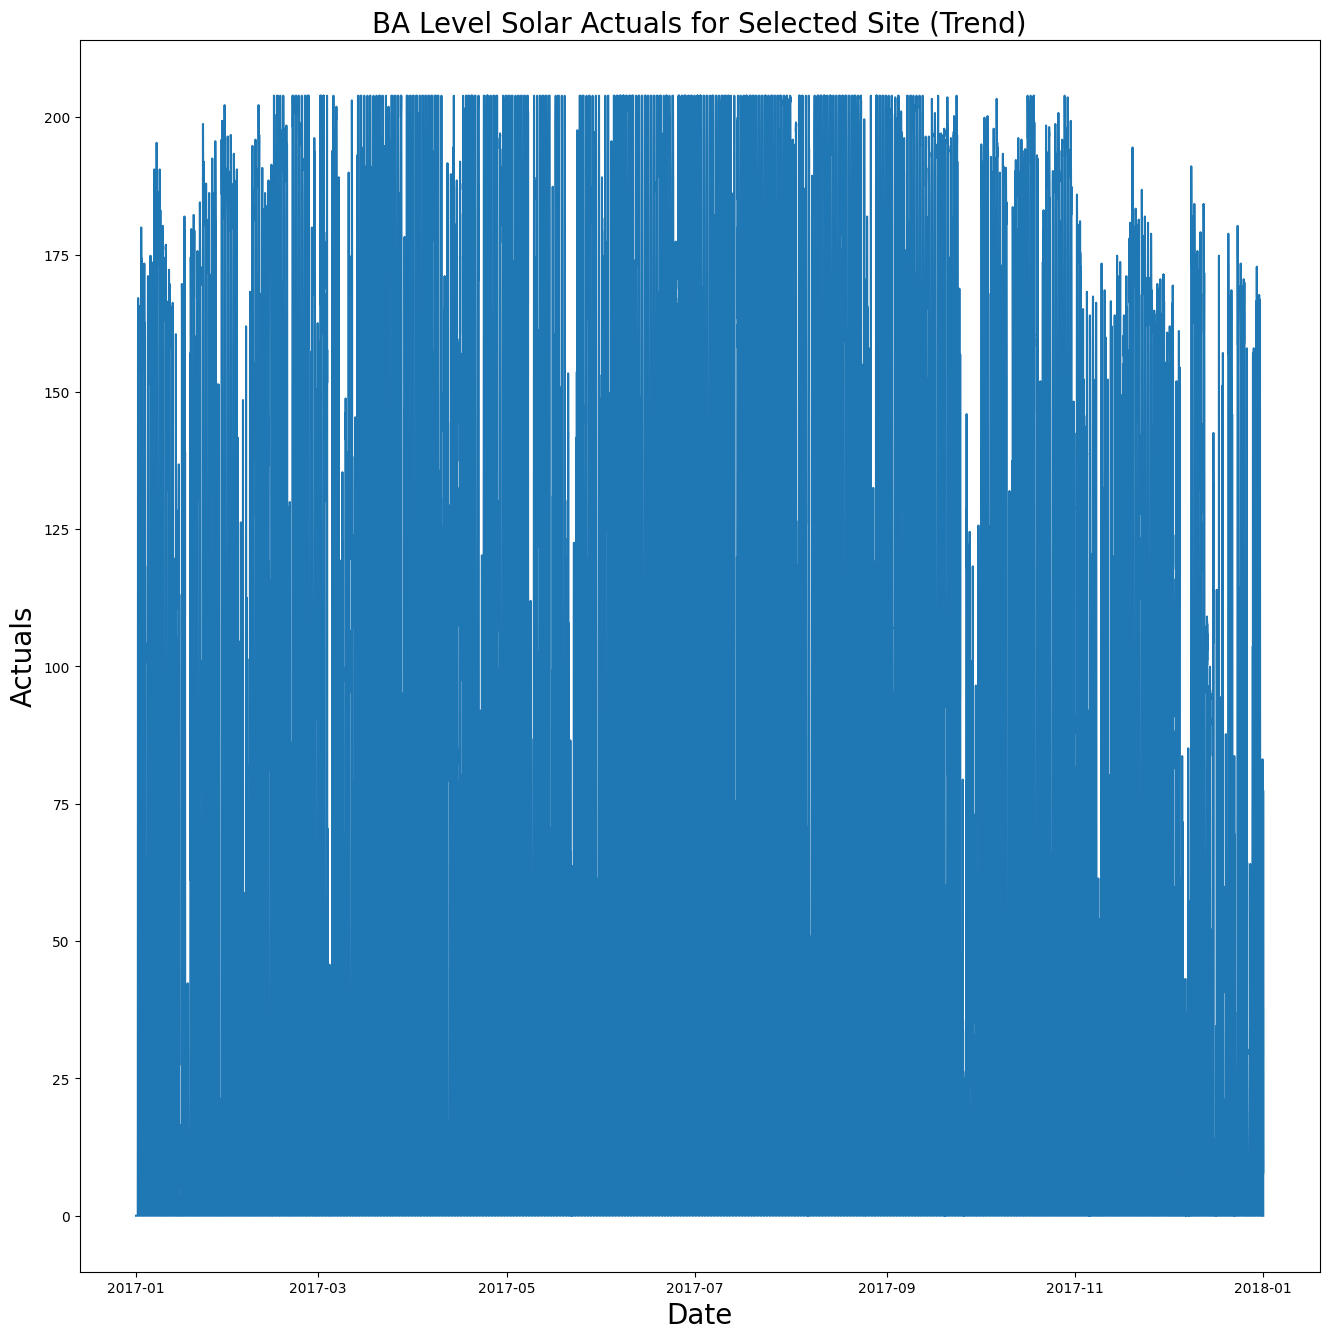

In [16]:
title_name = 'BA Level Solar Actuals for Selected Site'
plot_actual_solar(df_entire, 0, df_entire.shape[0]-1, "Trend", title_name,
                 'Actuals')

### Monthly Plots (Seasonality)

In [17]:
monthly_df = df_entire.query("time_index >= @pd.to_datetime('2017-05-01 00:00:00', utc=True) \
                       and time_index <= @pd.to_datetime('2017-06-01 00:00:00', utc=True)")
monthly_df

,actual
time_index,
2017-05-01 00:00:00+00:00,121.9512
2017-05-01 00:05:00+00:00,112.2408
2017-05-01 00:10:00+00:00,102.5304
2017-05-01 00:15:00+00:00,93.1056
2017-05-01 00:20:00+00:00,83.9664
...,...
2017-05-31 23:40:00+00:00,143.3712
2017-05-31 23:45:00+00:00,138.5160
2017-05-31 23:50:00+00:00,132.2328


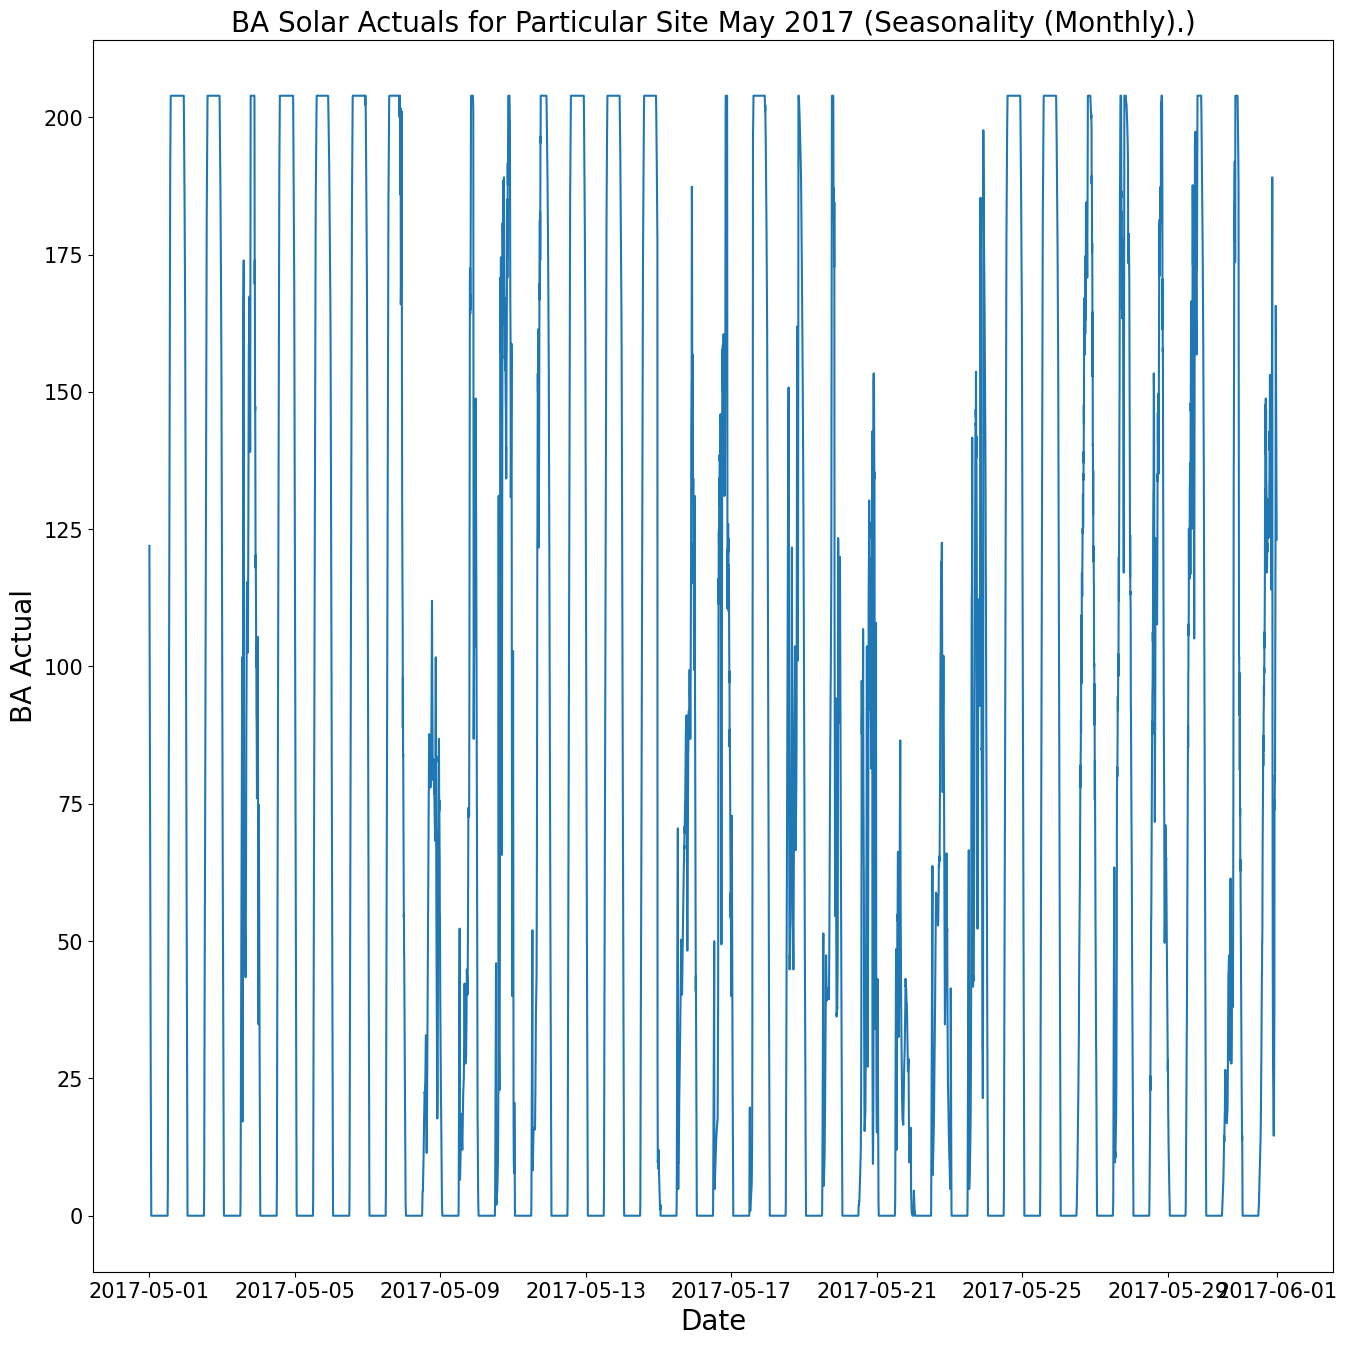

In [18]:
plot_actual_solar(monthly_df, 0, monthly_df.shape[0]-1, "Seasonality (Monthly).",
                 'BA Solar Actuals for Particular Site May 2017', 'BA Actual')

# Normalization Process

In [19]:
def get_scaler(scaler):
    scalers = {
        "minmax": MinMaxScaler,
        "standard": StandardScaler,
        "maxabs": MaxAbsScaler,
        "robust": RobustScaler,
    }
    return scalers.get(scaler.lower())()

def normalize_data(df):
    scaler_type = 'minmax'
    #scaler_type = input("Enter a scaler type (minmax,standard, maxabs, robust): ")
    if (scaler_type != 'minmax') and (scaler_type != 'standard') and (scaler_type != 'maxabs') and (scaler_type != 'robust'):
      runtime.unassign()

    scaler = get_scaler(scaler_type)
    normalized_data_BA_Actual = scaler.fit_transform(df['actual'].
                                               values.reshape(-1,1))
    df['Actual_Norm'] = normalized_data_BA_Actual
    return df, scaler

df_norm, scaler = normalize_data(df_entire)
df_norm_mon, scaler = normalize_data(monthly_df)

In [20]:
df_norm = df_norm.drop(columns = ['actual'])
df_norm

,Actual_Norm
time_index,
2017-01-01 00:00:00+00:00,0.000000
2017-01-01 00:05:00+00:00,0.000000
2017-01-01 00:10:00+00:00,0.000000
2017-01-01 00:15:00+00:00,0.000000
2017-01-01 00:20:00+00:00,0.000000
...,...
2017-12-31 23:35:00+00:00,0.004202
2017-12-31 23:40:00+00:00,0.009804
2017-12-31 23:45:00+00:00,0.000000


In [21]:
df_norm_mon = df_norm_mon.drop(columns = ['actual'])
df_norm_mon

,Actual_Norm
time_index,
2017-05-01 00:00:00+00:00,0.598039
2017-05-01 00:05:00+00:00,0.550420
2017-05-01 00:10:00+00:00,0.502801
2017-05-01 00:15:00+00:00,0.456583
2017-05-01 00:20:00+00:00,0.411765
...,...
2017-05-31 23:40:00+00:00,0.703081
2017-05-31 23:45:00+00:00,0.679272
2017-05-31 23:50:00+00:00,0.648459


## Plot BA Actual Normalized based on Trend and Seasonality.

Now after normalization we can observe that the data range on y-axis is 0.0 - 1.0.

### Trend Plot

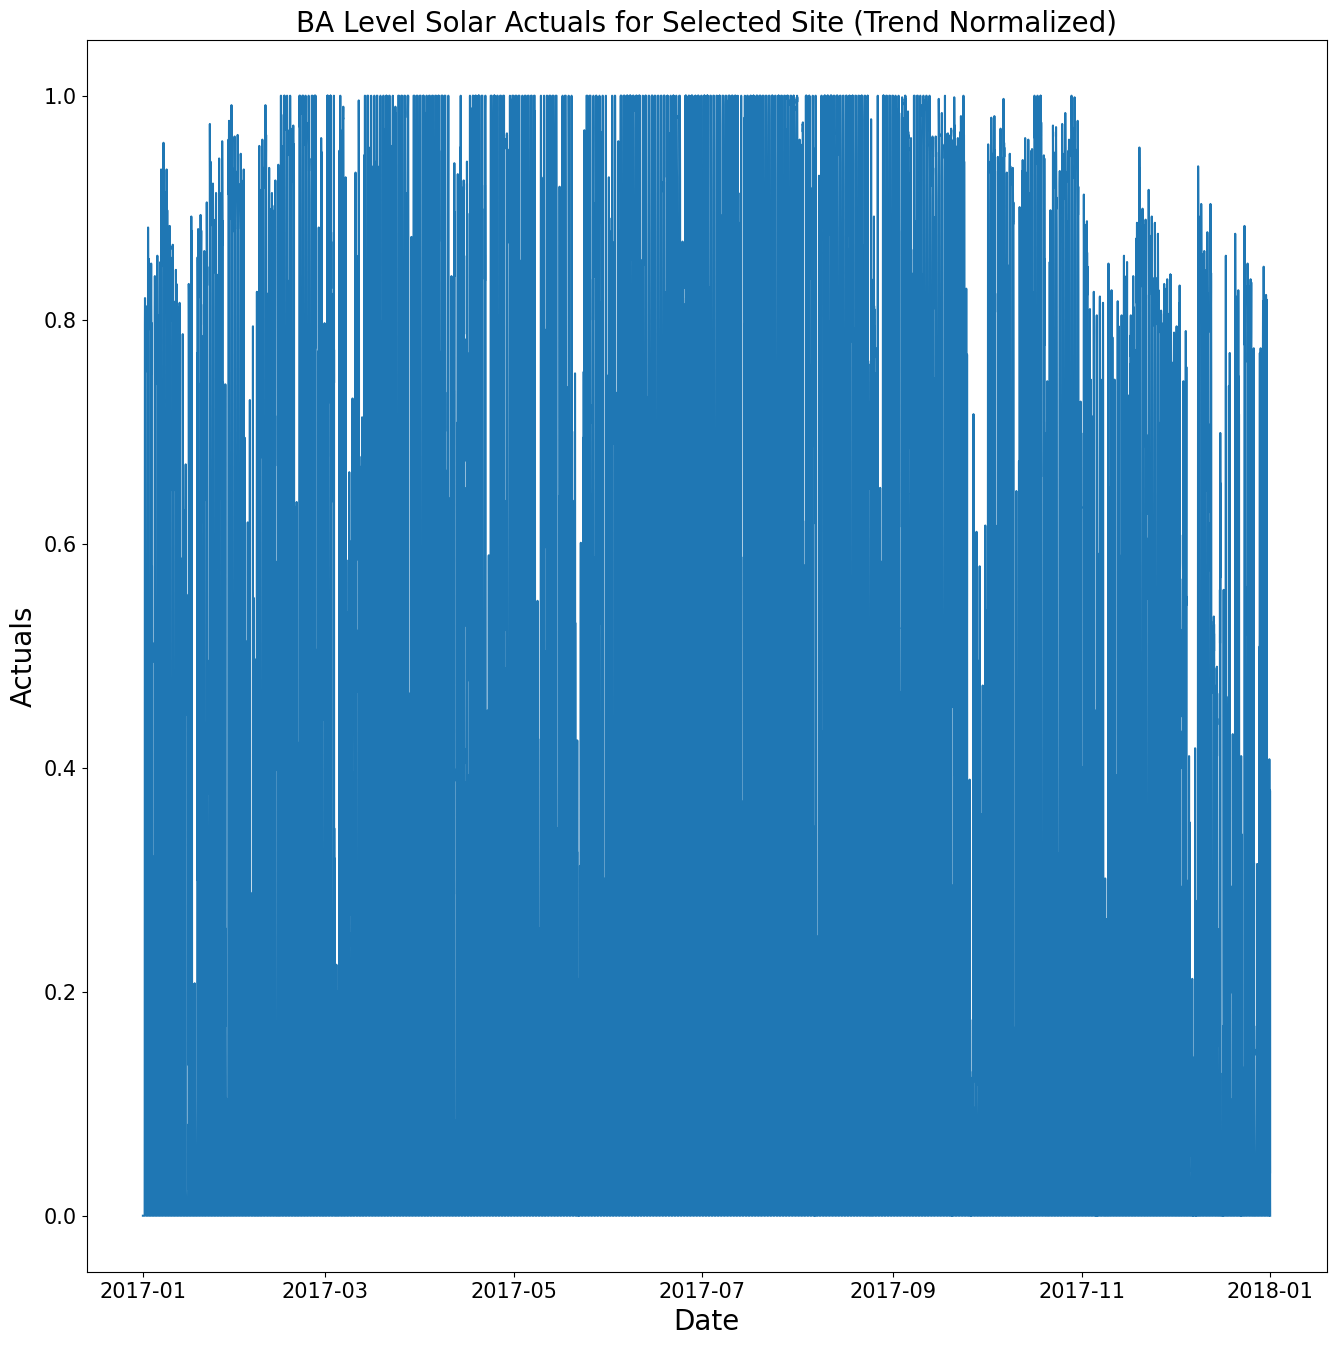

In [22]:
plot_actual_solar(df_norm, 0, df_norm.shape[0]-1, "Trend Normalized", title_name,
                 'Actuals')

### Monthly Plots (Seasonality)

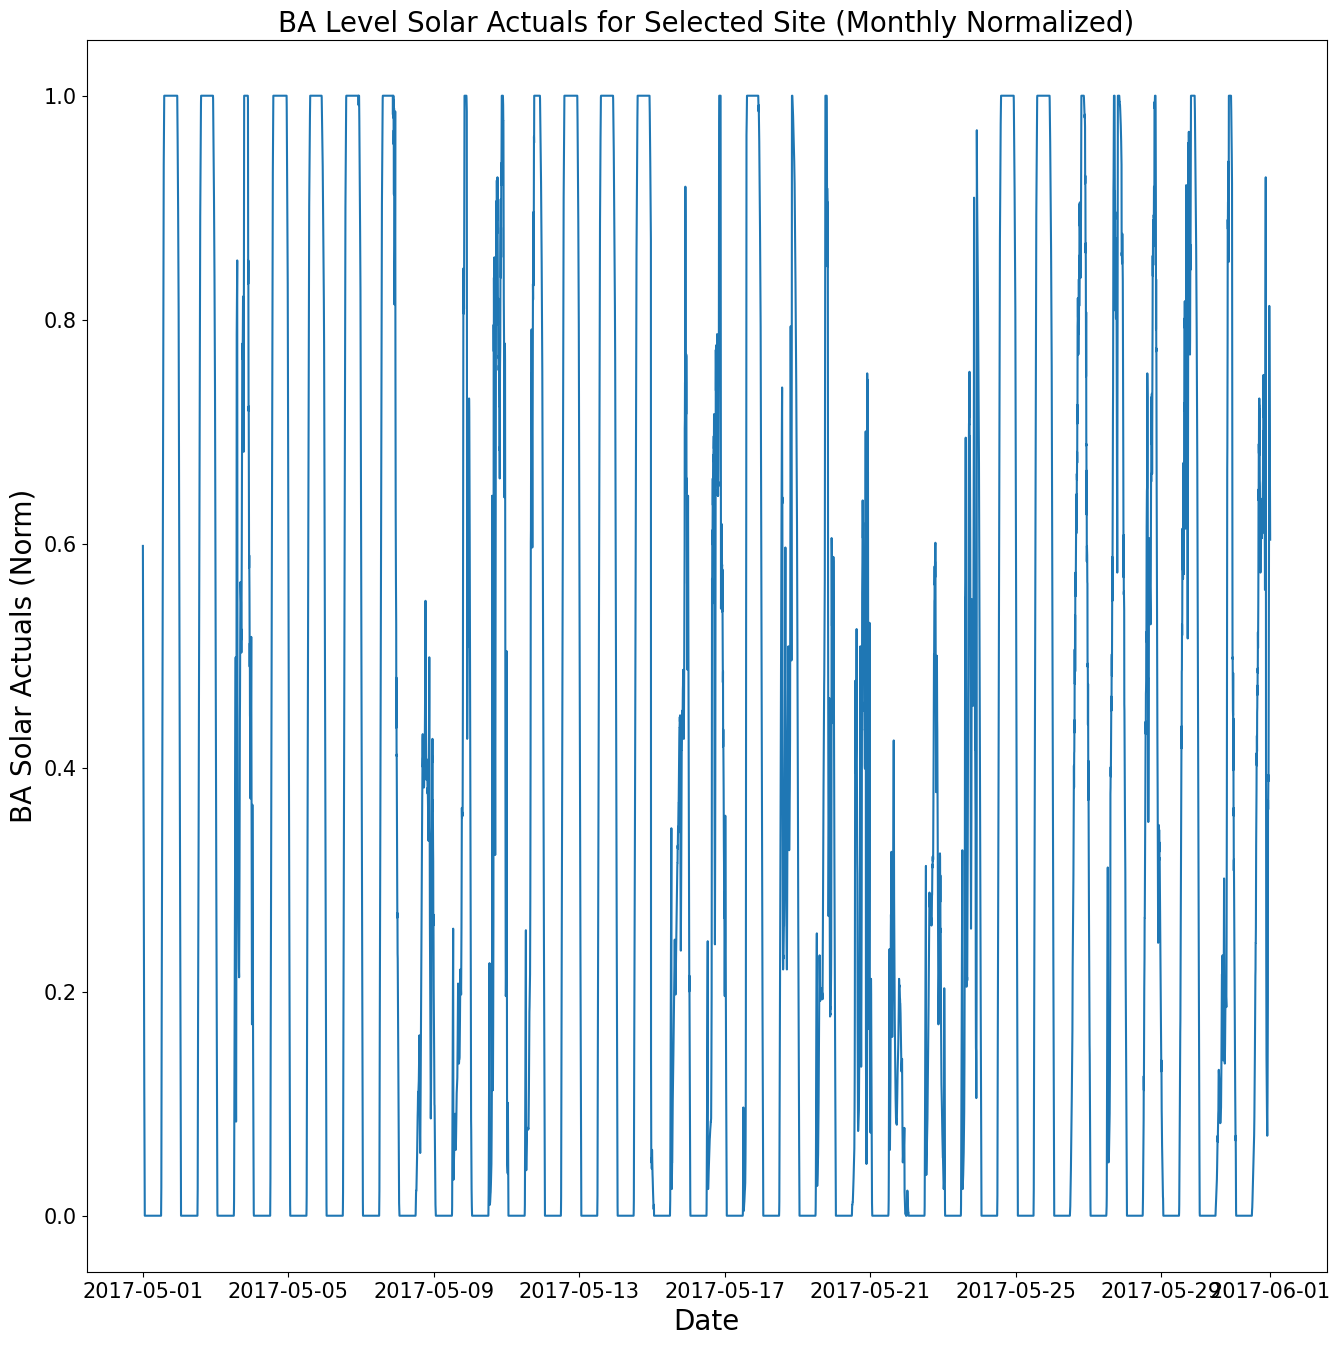

In [23]:
plot_actual_solar(df_norm_mon, 0, df_norm_mon.shape[0]-1, "Monthly Normalized",
                  title_name, 'BA Solar Actuals (Norm)')

# Let's observe train and test data on the graph

## Split into Train/Test Data.

In [24]:
test_size = 0.2 # Set Split rate to 3:1 (80 % Training 20 % Test).
split_pos = int(df_entire.shape[0]*(1 - test_size))
df_entire = df_entire.reset_index()
df_entire

,time_index,actual,Actual_Norm
0,2017-01-01 00:00:00+00:00,0.0000,0.000000
1,2017-01-01 00:05:00+00:00,0.0000,0.000000
2,2017-01-01 00:10:00+00:00,0.0000,0.000000
3,2017-01-01 00:15:00+00:00,0.0000,0.000000
4,2017-01-01 00:20:00+00:00,0.0000,0.000000
...,...,...,...
105115,2017-12-31 23:35:00+00:00,0.8568,0.004202
105116,2017-12-31 23:40:00+00:00,1.9992,0.009804
105117,2017-12-31 23:45:00+00:00,0.0000,0.000000
105118,2017-12-31 23:50:00+00:00,0.0000,0.000000


In [25]:
# 2019-02-06 will be the date seperation. Dates past this will be the test set.
split_date = str(df_entire.time_index[split_pos])
#split_date = split_date[:10]
#DOM_train = df_norm.loc[df_norm.index <= split_date].copy()
DOM_train = df_entire.loc[df_norm.index <= split_date].copy()
#DOM_test = df_norm.loc[df_norm.index > split_date].copy()
DOM_test = df_entire.loc[df_norm.index > split_date].copy()
split_date

'2017-10-20 00:00:00+00:00'

## Plot Train/Test Split Graphs.

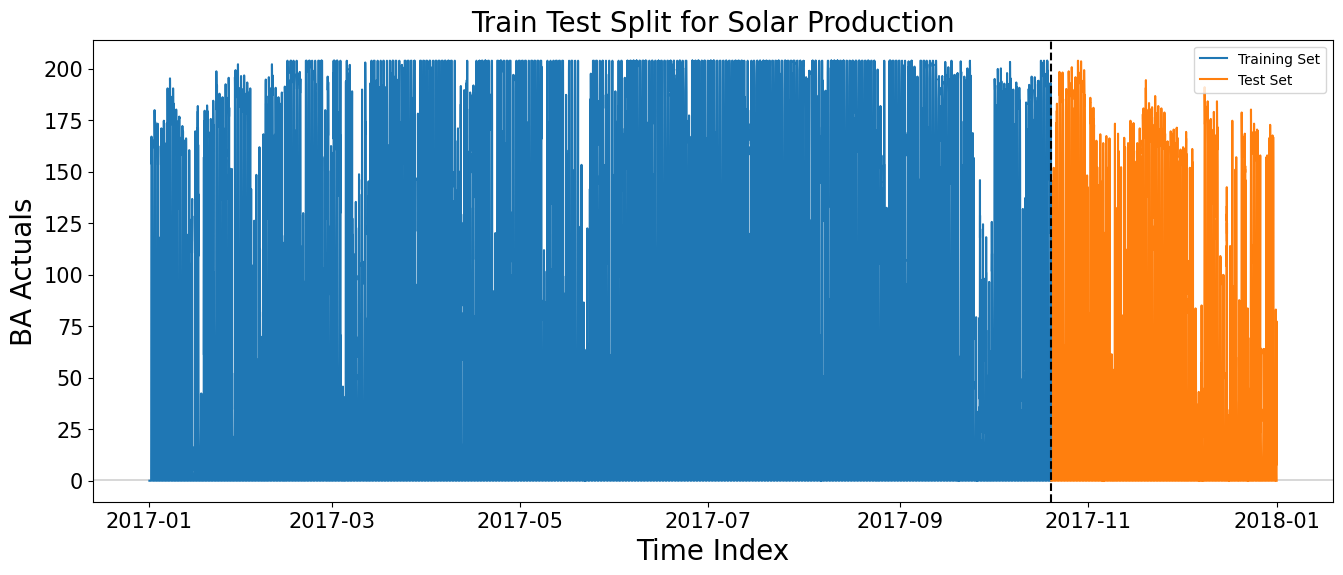

In [26]:
# Monthly Mean Total Sunspot Number Train Test Split
plt.figure(figsize=(16,6))
plt.plot(DOM_train['time_index'], DOM_train['actual'],
         label='Training Set')
plt.plot(DOM_test['time_index'], DOM_test['actual'],
         label='Testing Set')
plt.axvline(x = df_entire.time_index[split_pos], color='black', ls='--')
plt.legend(['Training Set', 'Test Set'])
plt.axhspan(0, 1, facecolor='gray', alpha=0.3)
plt.xlabel("Time Index", fontsize = 20)
plt.ylabel("BA Actuals", fontsize = 20)
plt.title("Train Test Split for Solar Production", fontsize = 20)
plt.show()

In [27]:
# We index the Datetime column after transformation
df_entire.set_index('time_index', inplace=True)
df_entire.head()

,actual,Actual_Norm
time_index,,
2017-01-01 00:00:00+00:00,0.0,0.0
2017-01-01 00:05:00+00:00,0.0,0.0
2017-01-01 00:10:00+00:00,0.0,0.0
2017-01-01 00:15:00+00:00,0.0,0.0
2017-01-01 00:20:00+00:00,0.0,0.0


In [28]:
df_entire1 = df_entire.drop(columns = ['Actual_Norm'])
df_entire1

,actual
time_index,
2017-01-01 00:00:00+00:00,0.0000
2017-01-01 00:05:00+00:00,0.0000
2017-01-01 00:10:00+00:00,0.0000
2017-01-01 00:15:00+00:00,0.0000
2017-01-01 00:20:00+00:00,0.0000
...,...
2017-12-31 23:35:00+00:00,0.8568
2017-12-31 23:40:00+00:00,1.9992
2017-12-31 23:45:00+00:00,0.0000


In [29]:
df_entire2 = df_entire.drop(columns = ['actual'])
df_entire2

,Actual_Norm
time_index,
2017-01-01 00:00:00+00:00,0.000000
2017-01-01 00:05:00+00:00,0.000000
2017-01-01 00:10:00+00:00,0.000000
2017-01-01 00:15:00+00:00,0.000000
2017-01-01 00:20:00+00:00,0.000000
...,...
2017-12-31 23:35:00+00:00,0.004202
2017-12-31 23:40:00+00:00,0.009804
2017-12-31 23:45:00+00:00,0.000000


# Prepare Data for Training the Models.

* With the following function block, let's set the data set as training and test data set in a model appropriate way

In [30]:
def load_data(data, seq_len, feature_column):
    X_train = []
    y_train = []

    for i in range(seq_len, len(data)):
        X_train.append(data[feature_column].iloc[i-seq_len : i])
        y_train.append(data[feature_column].iloc[i])

    # last days are going to be used in test
    X_test = X_train[split_pos:]
    y_test = y_train[split_pos:]

    # first  days are going to be used in training
    X_train = X_train[:split_pos]
    y_train = y_train[:split_pos]

    # convert to numpy array
    X_train = np.array(X_train)
    y_train = np.array(y_train)
    X_test = np.array(X_test)
    y_test = np.array(y_test)


    # reshape data to input into RNN, LSTM, and GRU models
    X_train = np.reshape(X_train, (X_train.shape[0], seq_len, 1))
    X_test = np.reshape(X_test, (X_test.shape[0], seq_len, 1))


    return [X_train, y_train, X_test, y_test]

* **The seq_len** parameter determines how far back the model will look at historical data, helping the model to capture time dependencies in a memory-aware way.
* If "seq_len" is too large, the model can become complex and prone to overlearning.

In [31]:
feature = 'actual'
#selected_df = df_entire1
selected_df = df_entire2
feature_norm = 'Actual_Norm'
feature_field = 'BA_Actual'

In [32]:
seq_len = 20
#seq_len = 6*24*30

# Let's create train, test data
X_train, y_train, X_test, y_test = load_data(selected_df, seq_len, feature_norm)
#X_train, y_train, X_test, y_test = load_data(df_norm2, seq_len)


print('X_train.shape = ',X_train.shape)
print('y_train.shape = ', y_train.shape)
print('X_test.shape = ', X_test.shape)
print('y_test.shape = ',y_test.shape)

X_train.shape =  (84096, 20, 1)
y_train.shape =  (84096,)
X_test.shape =  (21004, 20, 1)
y_test.shape =  (21004,)


In [33]:
X_train

array([[[0.        ],
        [0.        ],
        [0.        ],
        ...,
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        ...,
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        ...,
        [0.        ],
        [0.        ],
        [0.        ]],

       ...,

       [[0.10784314],
        [0.07142857],
        [0.01260504],
        ...,
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.07142857],
        [0.01260504],
        [0.        ],
        ...,
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.01260504],
        [0.        ],
        [0.        ],
        ...,
        [0.        ],
        [0.        ],
        [0.        ]]])

In [34]:
X_test

array([[[0.        ],
        [0.        ],
        [0.        ],
        ...,
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        ...,
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        ...,
        [0.        ],
        [0.        ],
        [0.        ]],

       ...,

       [[0.05882353],
        [0.05462185],
        [0.04901961],
        ...,
        [0.00840336],
        [0.00420168],
        [0.00980392]],

       [[0.05462185],
        [0.04901961],
        [0.04481793],
        ...,
        [0.00420168],
        [0.00980392],
        [0.        ]],

       [[0.04901961],
        [0.04481793],
        [0.04061625],
        ...,
        [0.00980392],
        [0.        ],
        [0.        ]]])

In [35]:
y_train

array([0., 0., 0., ..., 0., 0., 0.])

In [36]:
y_test

array([0., 0., 0., ..., 0., 0., 0.])

## Essential Variables.

In [37]:
epochs = 10
batch_size = 1000
#loss = 'MAE'
loss = 'MSE'
#activation = 'sigmoid'
activation = 'tanh'
#activation = 'relu'

## Training Loss vs. Epochs Plot

Plotting Accuracy and Validation Accuracy vs Epochs. Code taken from https://machinelearningmastery.com/display-deep-learning-model-training-history-in-keras/.

In [38]:
def plot_training_loss(model, model_name):
    model.history.keys()
    plt.plot(model.history['loss'])
    plt.title('Training Loss vs. Epochs for {0}'.format(model_name))
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.show()

## Measure Time vs. Energy

In [39]:
def measure_time_and_energy(model, x_test):
    """
    Measures inference time and estimates energy consumption for a given Keras model
    on both CPU and GPU (if available).

    Args:
        model: The Keras model to evaluate.
        x_test: The input data for inference.
    """
    # Define general power estimates (in Watts).
    general_cpu_power_watts = 80  # General CPU power under load
    general_gpu_power_watts = 65  # General GPU power under load
    num_samples = x_test.shape[0]

    print("Measuring inference time and estimating energy on CPU...")
    # Create a separate model instance on CPU for measurement.
    with tf.device('/CPU:0'):
        cpu_model = tf.keras.models.clone_model(model)
        # Build the cloned model with a dummy input to set input_shape attributes
        if not cpu_model.built:
            sample_input_shape = x_test.shape[1:]  # e.g., (seq_len, 1)
            cpu_model.build((None,) + sample_input_shape)

        # Copy weights to the CPU model
        for cpu_layer, gpu_layer in zip(cpu_model.layers, model.layers):
            cpu_layer.set_weights(gpu_layer.get_weights())

        # Check CPU Model Inference Time.
        start_time_cpu = time.time()
        _ = cpu_model.predict(x_test, verbose=0) # suppress verbose output
        end_time_cpu = time.time()
        cpu_inference_time = end_time_cpu - start_time_cpu
        print(f"Model CPU inference time: {cpu_inference_time:.4f} seconds")

        # Estimate energy consumption (Joules = Watts * Seconds)
        estimated_cpu_energy = general_cpu_power_watts * cpu_inference_time
        print(f"Estimated CPU energy consumption (using general power value): "
        f"{estimated_cpu_energy:.4f} J")

        # Convert to microjoules
        estimated_cpu_energy_microjoules = estimated_cpu_energy * 1e6
        total_params = model.count_params()
        # Heuristic for memory energy (e.g., 100 pJ per parameter access)
        memory_energy_picojoules = total_params * 100
        memory_energy_microjoules = memory_energy_picojoules / 1e6
        total_cpu_energy_microjoules = (
            estimated_cpu_energy_microjoules + memory_energy_microjoules)
        print(f"Total CPU Energy: {total_cpu_energy_microjoules:.4f} µJ")

    # Measure inference time and estimate energy on GPU if available.
    if tf.config.list_physical_devices('GPU'):
        print("\nMeasuring inference time and estimating energy on GPU...")
        with tf.device('/GPU:0'):
            # For GPU measurements, it's good practice to run a small warm-up
            # pass to ensure everything is loaded and ready on the GPU.
            _ = model.predict(x_test[:10], verbose=0) # Warm-up and suppress verbose output

            # Check Model GPU Inference Time.
            start_time_gpu = time.time()
            _ = model.predict(x_test, verbose=0) # suppress verbose output
            end_time_gpu = time.time()
            gpu_inference_time = end_time_gpu - start_time_gpu
            print(f"Estimated GPU inference time: {gpu_inference_time:.4f} seconds")

            # Estimate energy consumption (Joules = Watts * Seconds)
            estimated_gpu_energy = general_gpu_power_watts * gpu_inference_time
            print(f"Estimated GPU energy consumption (using general power "
            f"value): {estimated_gpu_energy:.4f} J")

            # Find Energy per sample by dividing GPU energy by number of samples.
            energy_per_sample_gpu = estimated_gpu_energy / num_samples
            print(f"Energy per sample: {energy_per_sample_gpu * 1e6:.4f} µJ")

            # Convert to microjoules
            estimated_gpu_energy_microjoules = estimated_gpu_energy * 1e6
            total_params = model.count_params()
            memory_energy_picojoules = total_params * 100  # 100 pJ per access
            memory_energy_microjoules = memory_energy_picojoules / 1e6
            total_gpu_energy_microjoules = (
                estimated_gpu_energy_microjoules + memory_energy_microjoules)

            # Calculated Total GPU Energy.
            print(f"Total GPU Energy: {total_gpu_energy_microjoules:.4f} µJ")

    else:
        print("\nNo GPU available in this runtime. Cannot measure GPU "
              "inference time or estimate energy.")

# LSTM model

## Create LSTM Model.

In [40]:
lstm_model = Sequential()

lstm_model.add(LSTM(8, activation=activation, return_sequences=False,
                   input_shape=(40,1)))
lstm_model.add(Dropout(0.5)) # Added to prevent overfitting

lstm_model.add(Dense(1))

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 8)              │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 329 (1.29 KB)

 Trainable params: 329 (1.29 KB)

 Non-trainable params: 0 (0.00 B)

## Training LSTM Model.

Epoch 1/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0788
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0376
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0312
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0281
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0266
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0249
Epoch 7/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0235
Epoch 8/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0226
Epoch 9/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0219
Epoch 10/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0215


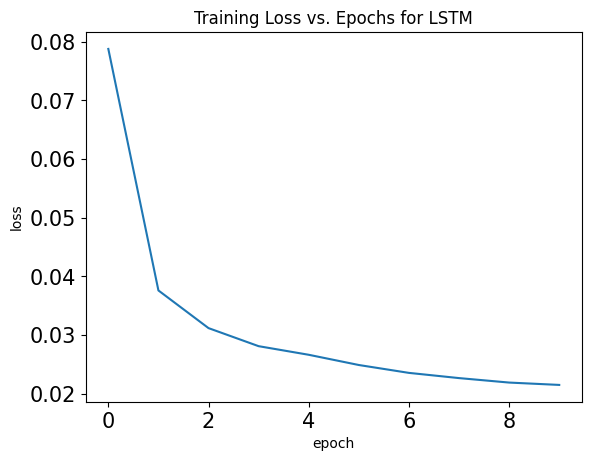

In [41]:
#lstm_model.compile(optimizer="adam",loss=loss)
# Compiled using
lstm_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                   loss=loss)
lstm_model_epochs = lstm_model.fit(X_train, y_train, epochs=epochs,
                           batch_size=batch_size)
plot_training_loss(lstm_model_epochs, "LSTM")

## Evaluate LSTM Model using MAE, RMSE, and R2.

In [42]:
print("RNN Predictions for Training Set")
lstm_predictions_train = lstm_model.predict(X_train)
print("RNN Predictions for Testing Set")
lstm_predictions_test = lstm_model.predict(X_test)
lstm_mae = mean_absolute_error(y_test,lstm_predictions_test)
print("MAE of RNN model = ",lstm_mae)
lstm_rmse =  mean_squared_error(y_test, lstm_predictions_test) ** 0.5
print("RMSE of RNN model = ", lstm_rmse)
#rnn_r2_score = r2_score(y_test,rnn_predictions_test)
#print("R2 Score of RNN model = ",rnn_r2_score)
lstm_mape_score = 100*mean_absolute_percentage_error(y_test,
                                                    lstm_predictions_test)
print("MAPE Score of RNN model = {0} %".format(lstm_mape_score))

RNN Predictions for Training Set
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step
RNN Predictions for Testing Set
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
MAE of RNN model =  0.050773711392222955
RMSE of RNN model =  0.06510868314518381
MAPE Score of RNN model = 9758184489166576.0 %


## Reverse Transform Scaler to Convert to Real Values.

In [43]:
y_train_inverse = scaler.inverse_transform(y_train.reshape(-1, 1))
lstm_predictions_inv_train = scaler.inverse_transform(lstm_predictions_train)

y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))
lstm_predictions_inv_test = scaler.inverse_transform(lstm_predictions_test)

# Get values after inverse transformation
y_train_inverse = y_train_inverse.flatten()
lstm_predictions_inv_train = lstm_predictions_inv_train.flatten()

y_test_inverse = y_test_inverse.flatten()
lstm_predictions_inv_test = lstm_predictions_inv_test.flatten()

## Show Actual and Predicted y values as Dataframes.

### With Training Dates.

In [44]:
first_6169_index_dates = df_entire.index[:X_train.shape[0]]
results_LSTM_train = pd.DataFrame({"Date": first_6169_index_dates,
                                  'Actual': y_train_inverse,
                                  'Predicted': lstm_predictions_inv_train})
results_LSTM_train

,Date,Actual,Predicted
0,2017-01-01 00:00:00+00:00,0.0,7.720604
1,2017-01-01 00:05:00+00:00,0.0,7.720604
2,2017-01-01 00:10:00+00:00,0.0,7.720604
3,2017-01-01 00:15:00+00:00,0.0,7.720604
4,2017-01-01 00:20:00+00:00,0.0,7.720604
...,...,...,...
84091,2017-10-19 23:35:00+00:00,0.0,7.581438
84092,2017-10-19 23:40:00+00:00,0.0,7.670737
84093,2017-10-19 23:45:00+00:00,0.0,7.712846
84094,2017-10-19 23:50:00+00:00,0.0,7.725518


### With Testing Dates.

In [45]:
last_6169_index_dates = df_entire.index[-X_test.shape[0]:]
results_LSTM_test = pd.DataFrame({"Date":last_6169_index_dates,
                                 'Actual': y_test_inverse,
                                 'Predicted': lstm_predictions_inv_test})
results_LSTM_test

,Date,Actual,Predicted
0,2017-10-20 01:40:00+00:00,0.0000,7.720604
1,2017-10-20 01:45:00+00:00,0.0000,7.720604
2,2017-10-20 01:50:00+00:00,0.0000,7.720604
3,2017-10-20 01:55:00+00:00,0.0000,7.720604
4,2017-10-20 02:00:00+00:00,0.0000,7.720604
...,...,...,...
20999,2017-12-31 23:35:00+00:00,0.8568,23.401949
21000,2017-12-31 23:40:00+00:00,1.9992,16.014006
21001,2017-12-31 23:45:00+00:00,0.0000,11.070468
21002,2017-12-31 23:50:00+00:00,0.0000,7.346601


## Plotting Predictions for Monthly Mean Sunspot Number made by LSTM Model.

### Only Testing Data.

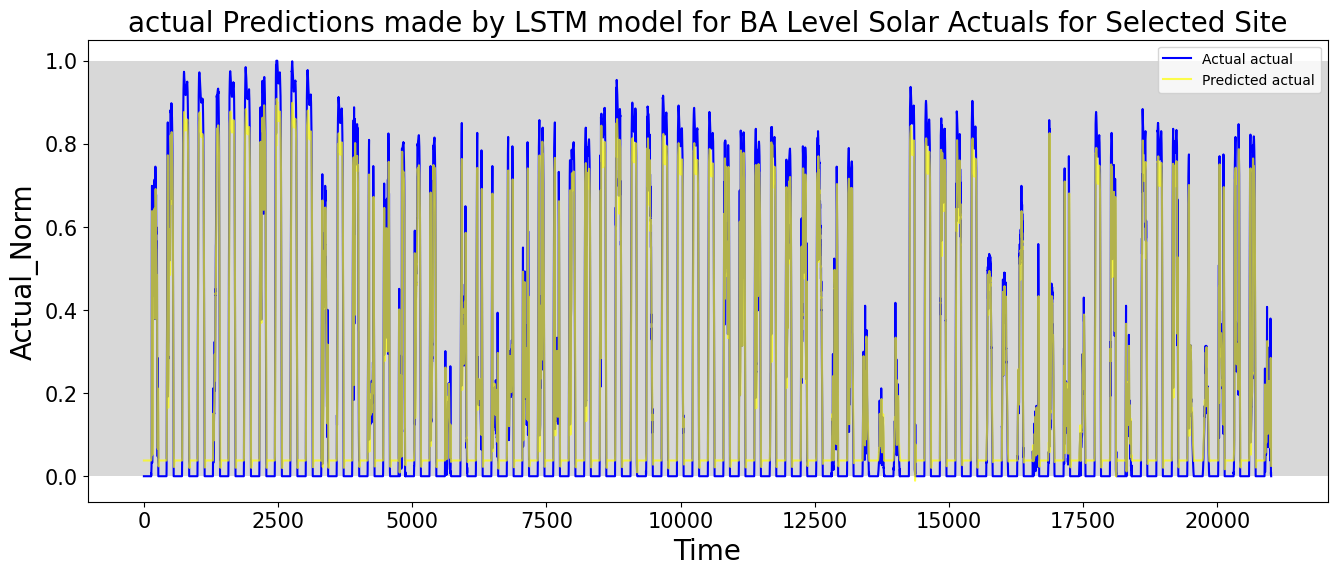

In [46]:
plt.figure(figsize=(16,6))
plt.plot(y_test, color='blue',label='Actual {0}'.format(feature))
plt.plot(lstm_predictions_test, alpha=0.7, color='yellow',
         label='Predicted {0}'.format(feature))
plt.axhspan(0, 1, facecolor='gray', alpha=0.3)
plt.title("{0} Predictions made by LSTM model for {1}".
          format(feature, title_name), fontsize = 20)
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
plt.locator_params(axis='x', nbins=10)
plt.locator_params(axis='y', nbins=10)
plt.xlabel('Time', fontsize = 20)
plt.ylabel(feature_norm, fontsize = 20)
plt.legend()
plt.show()

### Training and Testing Data combined.

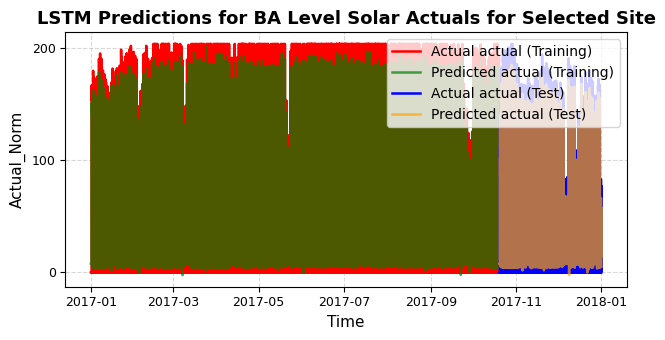

In [47]:
# 🔹 Create figure sized for IEEE 2-column layout
plt.figure(figsize=(6.5, 3.5))  # 6.5in width fits one column in IEEE

# 🔹 Plot training data
plt.plot(results_LSTM_train['Date'], results_LSTM_train['Actual'], color='red',
         label=f'Actual {feature} (Training)', linewidth=1.8)
plt.plot(results_LSTM_train['Date'], results_LSTM_train['Predicted'], color='green',
         label=f'Predicted {feature} (Training)', alpha=0.7, linewidth=1.8)

# 🔹 Plot test data
plt.plot(results_LSTM_test['Date'], results_LSTM_test['Actual'], color='blue',
         label=f'Actual {feature} (Test)', linewidth=1.8)
plt.plot(results_LSTM_test['Date'], results_LSTM_test['Predicted'], color='orange',
         label=f'Predicted {feature} (Test)', alpha=0.7, linewidth=1.8)

# 🔹 Formatting
plt.title(f'LSTM Predictions for {title_name}', fontsize=13, fontweight='bold')
plt.xlabel('Time', fontsize=11)
plt.ylabel(feature_norm, fontsize=11)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# 🔹 Export for Appendix
plt.show()

## Combine Actual and Predicted Results for Train and Test Cases for LSTM.

In [48]:
results_LSTM = [results_LSTM_train, results_LSTM_test]
results_LSTM = pd.concat(results_LSTM)
display(results_LSTM)

,Date,Actual,Predicted
0,2017-01-01 00:00:00+00:00,0.0000,7.720604
1,2017-01-01 00:05:00+00:00,0.0000,7.720604
2,2017-01-01 00:10:00+00:00,0.0000,7.720604
3,2017-01-01 00:15:00+00:00,0.0000,7.720604
4,2017-01-01 00:20:00+00:00,0.0000,7.720604
...,...,...,...
20999,2017-12-31 23:35:00+00:00,0.8568,23.401949
21000,2017-12-31 23:40:00+00:00,1.9992,16.014006
21001,2017-12-31 23:45:00+00:00,0.0000,11.070468
21002,2017-12-31 23:50:00+00:00,0.0000,7.346601


## Plotting Residuals for Actual and Predicted Results for LSTM.

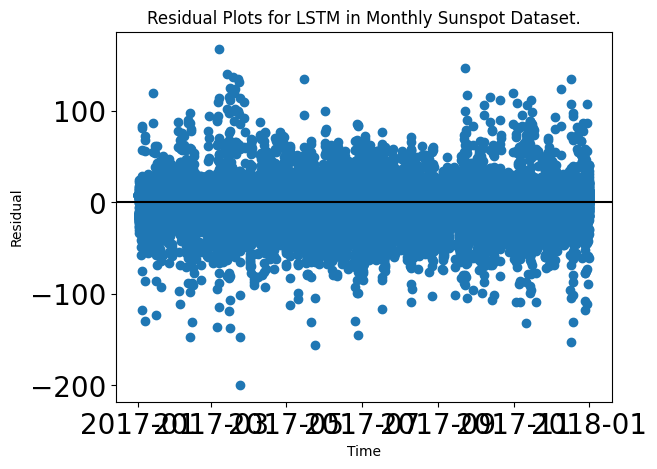

In [49]:
actual_arr_LSTM = np.array(results_LSTM['Actual'])
predicted_arr_LSTM = np.array(results_LSTM['Predicted'])
residuals_LSTM = predicted_arr_LSTM - actual_arr_LSTM
plt.scatter(results_LSTM['Date'], residuals_LSTM)
plt.axhline(y=0, color = 'black')
plt.title("Residual Plots for LSTM in Monthly Sunspot Dataset.")
#plt.locator_params(axis='x', nbins=10)
#plt.locator_params(axis='y', nbins=10)
#plt.ylim([40, 70])
plt.xlabel("Time")
plt.ylabel("Residual")
plt.show()

From the residual plots for the RNN model, it can be concluded that the RNN model is a good fit.

## Energy Consumption

In [50]:
measure_time_and_energy(lstm_model, X_test)

Measuring inference time and estimating energy on CPU...
Model CPU inference time: 2.9888 seconds
Estimated CPU energy consumption (using general power value): 239.1036 J
Total CPU Energy: 239103622.4694 µJ

No GPU available in this runtime. Cannot measure GPU inference time or estimate energy.


# GRU Model

## Create GRU Model.

In [51]:
gru_model = Sequential()

gru_model.add(GRU(8,activation=activation, return_sequences=False,
                  input_shape=(40,1)))
gru_model.add(Dropout(0.5))

gru_model.add(Dense(1))

gru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

## Train GRU Model.

Epoch 1/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0963
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0446
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0342
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0284
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0251
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0228
Epoch 7/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0215
Epoch 8/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0210
Epoch 9/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0204
Epoch 10/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0201


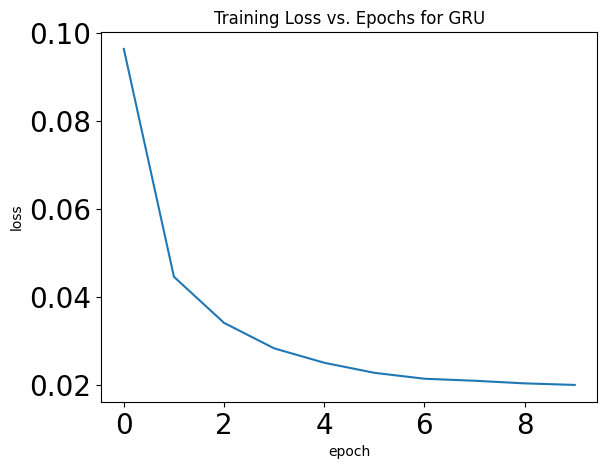

In [52]:
gru_model.compile(optimizer="adam",loss=loss)
gru_epochs = gru_model.fit(X_train, y_train, epochs=epochs,
                           batch_size=batch_size)
plot_training_loss(gru_epochs, "GRU")

## Evaluate GRU model using MAE, RMSE, and R^2.

In [53]:
print("GRU Predictions for Training Set")
gru_pred_train = gru_model.predict(X_train)
print("GRU Predictions for Testing Set")
gru_pred_test = gru_model.predict(X_test)
gru_mae = mean_absolute_error(y_test,gru_pred_test)
print("MAE of GRU model = ",gru_mae)
gru_rmse =  mean_squared_error(y_test,gru_pred_test) ** 0.5
print("RMSE of GRU model = ",gru_rmse)
#gru_r2_score = r2_score(y_test, gru_pred_test)
#print("R^2 Score of GRU model = ",gru_r2_score)
gru_mape_score = 100*mean_absolute_percentage_error(y_test, gru_pred_test)
print("MAPE Score of GRU model = {0} %".format(gru_mape_score))

GRU Predictions for Training Set
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step
GRU Predictions for Testing Set
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
MAE of GRU model =  0.044870972871961526
RMSE of GRU model =  0.05571538989068921
MAPE Score of GRU model = 9507649242072118.0 %


## Reverse transform scaler to convert to real values.

In [54]:
y_train_inverse = scaler.inverse_transform(y_train.reshape(-1, 1))
gru_pred_inv_train = scaler.inverse_transform(gru_pred_train)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))
gru_pred_inv_test = scaler.inverse_transform(gru_pred_test)

# Get values after inverse transformation
y_train_inverse = y_train_inverse.flatten()
gru_pred_inv_train = gru_pred_inv_train.flatten()
y_test_inverse = y_test_inverse.flatten()
gru_pred_inv_test = gru_pred_inv_test.flatten()

## Showing Actual y and Predicted y values as Dataframes.

### With Training Dates.

In [55]:
results_GRU_train = pd.DataFrame({"Date":first_6169_index_dates,
                            'Actual': y_train_inverse,
                            'Predicted': gru_pred_inv_train})
results_GRU_train

,Date,Actual,Predicted
0,2017-01-01 00:00:00+00:00,0.0,7.467119
1,2017-01-01 00:05:00+00:00,0.0,7.467119
2,2017-01-01 00:10:00+00:00,0.0,7.467119
3,2017-01-01 00:15:00+00:00,0.0,7.467119
4,2017-01-01 00:20:00+00:00,0.0,7.467119
...,...,...,...
84091,2017-10-19 23:35:00+00:00,0.0,7.467092
84092,2017-10-19 23:40:00+00:00,0.0,7.467144
84093,2017-10-19 23:45:00+00:00,0.0,7.467134
84094,2017-10-19 23:50:00+00:00,0.0,7.467125


### With Testing Dates.

In [56]:
results_GRU_test = pd.DataFrame({"Date":last_6169_index_dates,
                            'Actual': y_test_inverse,
                            'Predicted': gru_pred_inv_test})
results_GRU_test

,Date,Actual,Predicted
0,2017-10-20 01:40:00+00:00,0.0000,7.467119
1,2017-10-20 01:45:00+00:00,0.0000,7.467119
2,2017-10-20 01:50:00+00:00,0.0000,7.467119
3,2017-10-20 01:55:00+00:00,0.0000,7.467119
4,2017-10-20 02:00:00+00:00,0.0000,7.467119
...,...,...,...
20999,2017-12-31 23:35:00+00:00,0.8568,10.767599
21000,2017-12-31 23:40:00+00:00,1.9992,7.997006
21001,2017-12-31 23:45:00+00:00,0.0000,7.984675
21002,2017-12-31 23:50:00+00:00,0.0000,7.878536


## Plotting Predictions for AEP_MW made by GRU Model.

### Testing Data Only.

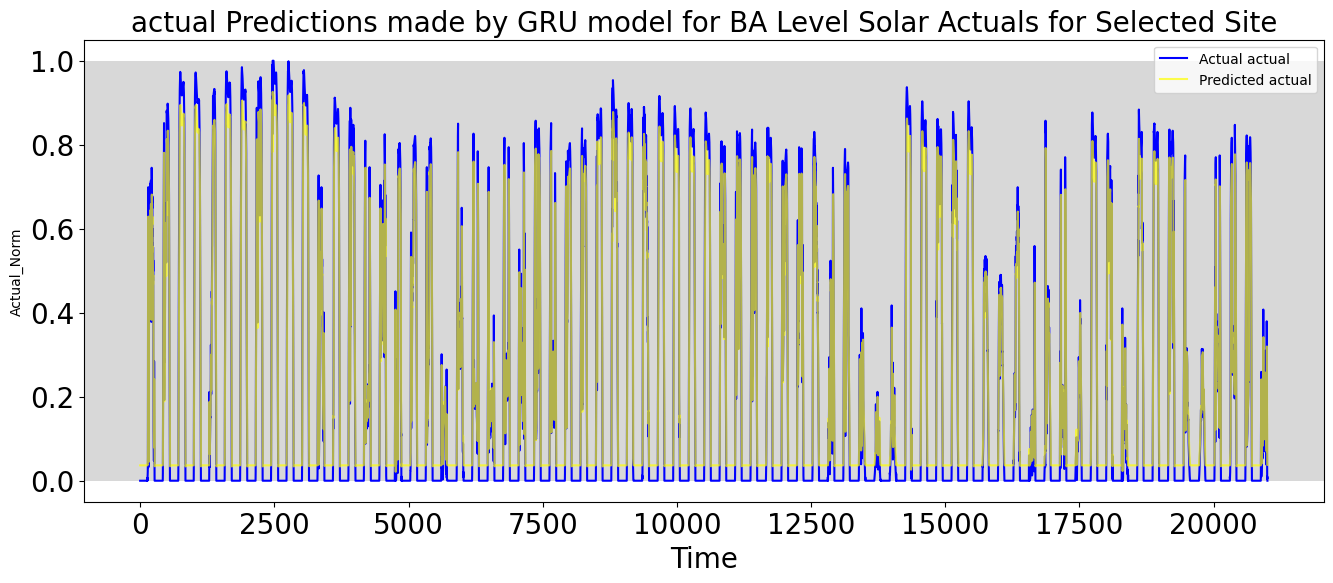

In [57]:
plt.figure(figsize=(16,6))
plt.plot(y_test, color='blue',label='Actual {0}'.format(feature))
plt.plot(gru_pred_test, alpha=0.7, color='yellow',
         label='Predicted {0}'.format(feature))
plt.axhspan(0, 1, facecolor='gray', alpha=0.3)
plt.title("{0} Predictions made by GRU model for {1}".
          format(feature, title_name), fontsize = 20)
plt.locator_params(axis='x', nbins=10)
plt.locator_params(axis='y', nbins=10)
#plt.ylim([40, 70])
plt.xlabel('Time', fontsize = 20)
plt.ylabel(feature_norm, fontsize = 10)
plt.legend()
plt.show()

### Training and Test Data Combined.

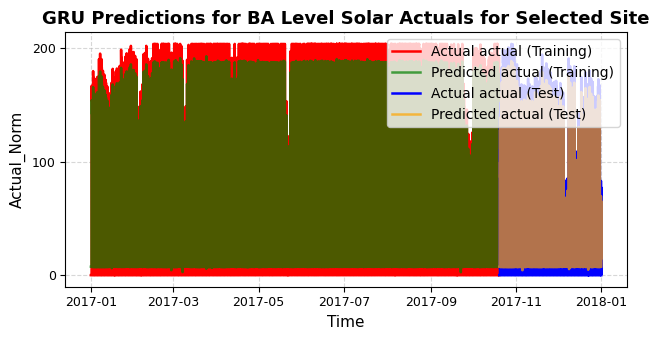

In [58]:
# 🔹 Create figure sized for IEEE 2-column layout
plt.figure(figsize=(6.5, 3.5))  # 6.5in width fits one column in IEEE

# 🔹 Plot training data
plt.plot(results_GRU_train['Date'], results_GRU_train['Actual'], color='red',
         label=f'Actual {feature} (Training)', linewidth=1.8)
plt.plot(results_GRU_train['Date'], results_GRU_train['Predicted'], color='green',
         label=f'Predicted {feature} (Training)', alpha=0.7, linewidth=1.8)

# 🔹 Plot test data
plt.plot(results_GRU_test['Date'], results_GRU_test['Actual'], color='blue',
         label=f'Actual {feature} (Test)', linewidth=1.8)
plt.plot(results_GRU_test['Date'], results_GRU_test['Predicted'], color='orange',
         label=f'Predicted {feature} (Test)', alpha=0.7, linewidth=1.8)

# 🔹 Formatting
plt.title(f'GRU Predictions for {title_name}', fontsize=13, fontweight='bold')
plt.xlabel('Time', fontsize=11)
plt.ylabel(feature_norm, fontsize=11)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# 🔹 Export for Appendix
plt.show()

## Combine Actual and Predicted Results for Train and Test Cases for GRU.

In [59]:
results_GRU = [results_GRU_train, results_GRU_test]
results_GRU = pd.concat(results_GRU)
display(results_GRU)

,Date,Actual,Predicted
0,2017-01-01 00:00:00+00:00,0.0000,7.467119
1,2017-01-01 00:05:00+00:00,0.0000,7.467119
2,2017-01-01 00:10:00+00:00,0.0000,7.467119
3,2017-01-01 00:15:00+00:00,0.0000,7.467119
4,2017-01-01 00:20:00+00:00,0.0000,7.467119
...,...,...,...
20999,2017-12-31 23:35:00+00:00,0.8568,10.767599
21000,2017-12-31 23:40:00+00:00,1.9992,7.997006
21001,2017-12-31 23:45:00+00:00,0.0000,7.984675
21002,2017-12-31 23:50:00+00:00,0.0000,7.878536


## Plotting Residuals for Actual and Predicted Results for GRU.

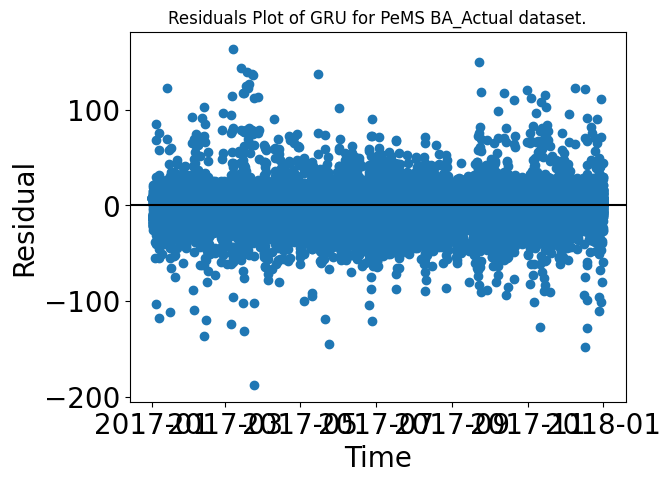

In [60]:
# Plotting Residuals for Actual and Predicted Results for GRU.
actual_arr_GRU = np.array(results_GRU['Actual'])
predicted_arr_GRU = np.array(results_GRU['Predicted'])
residuals_GRU = predicted_arr_GRU - actual_arr_GRU
plt.scatter(results_GRU['Date'], residuals_GRU)
plt.axhline(y=0, color = 'black')
plt.title("Residuals Plot of GRU for PeMS {} dataset.".format(feature_field))
#plt.locator_params(axis='x', nbins=10)
#plt.locator_params(axis='y', nbins=10)
#plt.ylim([40, 70])
plt.xlabel("Time", fontsize = 20)
plt.ylabel("Residual", fontsize = 20)
plt.show()

From the residual plots for the GRU model, it can be concluded that the GRU model is a good fit.

## Energy Consumption

In [61]:
measure_time_and_energy(gru_model, X_test)

Measuring inference time and estimating energy on CPU...
Model CPU inference time: 2.3341 seconds
Estimated CPU energy consumption (using general power value): 186.7249 J
Total CPU Energy: 186724929.8369 µJ

No GPU available in this runtime. Cannot measure GPU inference time or estimate energy.


# CNN (Conv1D) model

### Create CNN Model.

In [62]:
cnn_model = Sequential()

cnn_model.add(Conv1D(filters=8, kernel_size=3, activation=activation,
                     input_shape=(20,1)))
cnn_model.add(MaxPooling1D(pool_size=2))

cnn_model.add(Conv1D(filters=8, kernel_size=3, activation=activation,
                     input_shape=(20,1)))
cnn_model.add(MaxPooling1D(pool_size=2))

cnn_model.add(Flatten())
cnn_model.add(Dense(16, activation=activation))
cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(1))
cnn_model.compile(optimizer='adam', loss='mse')
cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 18, 8)          │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 9, 8)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 7, 8)           │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 3, 8)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649 (2.54 KB)

 Trainable params: 649 (2.54 KB)

 Non-trainable params: 0 (0.00 B)

### Train CNN model.

Epoch 1/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.1058
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0387
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0310
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0275
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0251
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0231
Epoch 7/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0218
Epoch 8/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0205
Epoch 9/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0200
Epoch 10/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0193


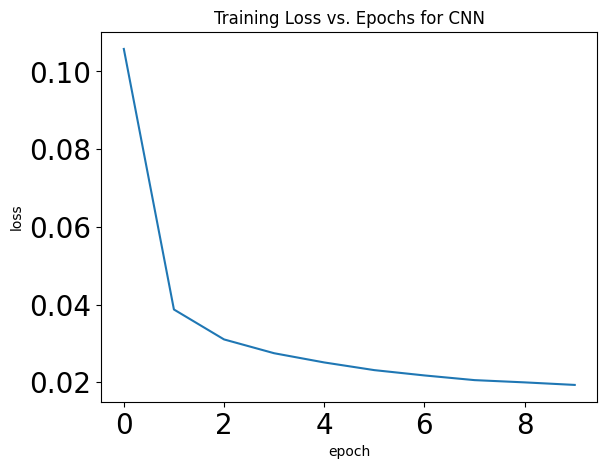

In [63]:
cnn_model.compile(optimizer="adam",loss=loss)
cnn_epochs = cnn_model.fit(X_train, y_train, epochs=epochs,
                           batch_size=batch_size)
plot_training_loss(cnn_epochs, "CNN")

### Evaluate CNN model using MAE, RMSE, and R^2.

In [64]:
print("CNN Predictions for Training Set")
cnn_pred_train = cnn_model.predict(X_train)
print("CNN Predictions for Testing Set")
cnn_pred_test = cnn_model.predict(X_test)
cnn_mae = mean_absolute_error(y_test,cnn_pred_test)
print("MAE of CNN model = ",cnn_mae)
cnn_rmse =  mean_squared_error(y_test,cnn_pred_test) ** 0.5
print("RMSE of CNN model = ",cnn_rmse)
#cnn_r2_score = r2_score(y_test, cnn_pred_test)
#print("R^2 Score of CNN model = ",cnn_r2_score)
cnn_mape_score = 100*mean_absolute_percentage_error(y_test, cnn_pred_test)
print("MAPE Score of CNN model = {0} %".format(cnn_mape_score))

CNN Predictions for Training Set
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
CNN Predictions for Testing Set
657/657 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
MAE of CNN model =  0.054208714839468854
RMSE of CNN model =  0.08858233854065674
MAPE Score of CNN model = 7765088276747269.0 %


### Reverse transform scaler to convert to real values.

In [65]:
y_train_inverse = scaler.inverse_transform(y_train.reshape(-1, 1))
cnn_pred_inv_train = scaler.inverse_transform(cnn_pred_train)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))
cnn_pred_inv_test = scaler.inverse_transform(cnn_pred_test)

# Get values after inverse transformation
y_train_inverse = y_train_inverse.flatten()
cnn_pred_inv_train = cnn_pred_inv_train.flatten()
y_test_inverse = y_test_inverse.flatten()
cnn_pred_inv_test = cnn_pred_inv_test.flatten()

### Showing Actual y and Predicted y values as Dataframes.

#### With Training Dates.

In [66]:
results_CNN_train = pd.DataFrame({"Date":first_6169_index_dates,
                                 'Actual': y_train_inverse,
                                 'Predicted': cnn_pred_inv_train})
results_CNN_train

,Date,Actual,Predicted
0,2017-01-01 00:00:00+00:00,0.0,6.139057
1,2017-01-01 00:05:00+00:00,0.0,6.139057
2,2017-01-01 00:10:00+00:00,0.0,6.139057
3,2017-01-01 00:15:00+00:00,0.0,6.139057
4,2017-01-01 00:20:00+00:00,0.0,6.139057
...,...,...,...
84091,2017-10-19 23:35:00+00:00,0.0,2.405315
84092,2017-10-19 23:40:00+00:00,0.0,3.486863
84093,2017-10-19 23:45:00+00:00,0.0,5.129034
84094,2017-10-19 23:50:00+00:00,0.0,5.690210


#### With Testing Dates.

In [67]:
results_CNN_test = pd.DataFrame({"Date":last_6169_index_dates,
                                 'Actual': y_test_inverse,
                                 'Predicted': cnn_pred_inv_test})
results_CNN_test

,Date,Actual,Predicted
0,2017-10-20 01:40:00+00:00,0.0000,6.139057
1,2017-10-20 01:45:00+00:00,0.0000,6.139057
2,2017-10-20 01:50:00+00:00,0.0000,6.139057
3,2017-10-20 01:55:00+00:00,0.0000,6.139057
4,2017-10-20 02:00:00+00:00,0.0000,6.139057
...,...,...,...
20999,2017-12-31 23:35:00+00:00,0.8568,44.316387
21000,2017-12-31 23:40:00+00:00,1.9992,9.776812
21001,2017-12-31 23:45:00+00:00,0.0000,-4.742512
21002,2017-12-31 23:50:00+00:00,0.0000,-22.941488


### Plotting Predictions for AEP_MW made by CNN Model.

#### Only Testing Data.

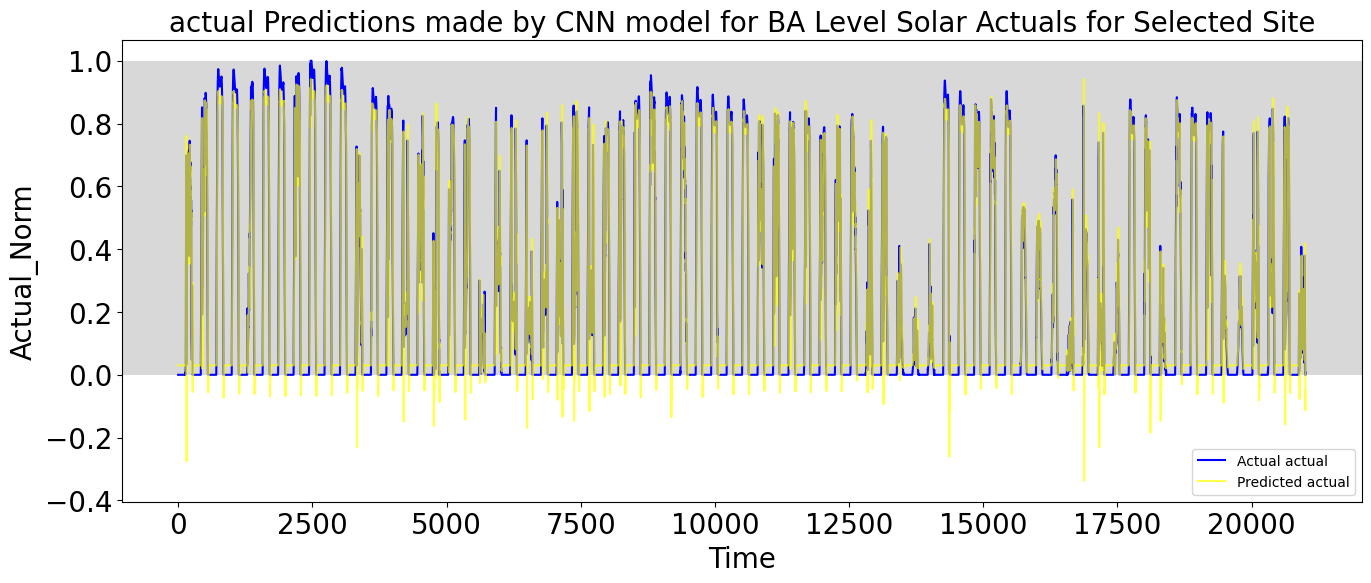

In [68]:
plt.figure(figsize=(16,6))
plt.plot(y_test, color='blue',label='Actual {0}'.format(feature))
plt.plot(cnn_pred_test, alpha=0.7, color='yellow',
         label='Predicted {0}'.format(feature))
plt.axhspan(0, 1, facecolor='gray', alpha=0.3)
plt.title("{0} Predictions made by CNN model for {1}".
          format(feature, title_name), fontsize = 20)
plt.locator_params(axis='x', nbins=10)
plt.locator_params(axis='y', nbins=10)
#plt.ylim([40, 70])
plt.xlabel('Time', fontsize = 20)
plt.ylabel(feature_norm, fontsize = 20)
plt.legend()
plt.show()

#### Training and Test Data Combined.

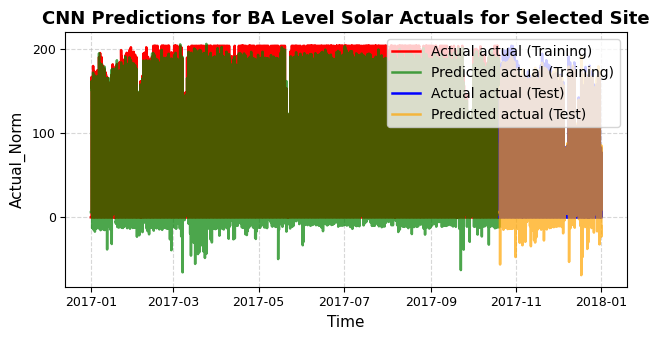

In [69]:
# 🔹 Create figure sized for IEEE 2-column layout
plt.figure(figsize=(6.5, 3.5))  # 6.5in width fits one column in IEEE

# 🔹 Plot training data
plt.plot(results_CNN_train['Date'], results_CNN_train['Actual'], color='red',
         label=f'Actual {feature} (Training)', linewidth=1.8)
plt.plot(results_CNN_train['Date'], results_CNN_train['Predicted'], color='green',
         label=f'Predicted {feature} (Training)', alpha=0.7, linewidth=1.8)

# 🔹 Plot test data
plt.plot(results_CNN_test['Date'], results_CNN_test['Actual'], color='blue',
         label=f'Actual {feature} (Test)', linewidth=1.8)
plt.plot(results_CNN_test['Date'], results_CNN_test['Predicted'], color='orange',
         label=f'Predicted {feature} (Test)', alpha=0.7, linewidth=1.8)

# 🔹 Formatting
plt.title(f'CNN Predictions for {title_name}', fontsize=13, fontweight='bold')
plt.xlabel('Time', fontsize=11)
plt.ylabel(feature_norm, fontsize=11)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# 🔹 Export for Appendix
plt.show()

### Combine Actual and Predicted Results for Train and Test Cases for CNN.

In [70]:
results_CNN = [results_CNN_train, results_CNN_test]
results_CNN = pd.concat(results_CNN)
display(results_CNN)

,Date,Actual,Predicted
0,2017-01-01 00:00:00+00:00,0.0000,6.139057
1,2017-01-01 00:05:00+00:00,0.0000,6.139057
2,2017-01-01 00:10:00+00:00,0.0000,6.139057
3,2017-01-01 00:15:00+00:00,0.0000,6.139057
4,2017-01-01 00:20:00+00:00,0.0000,6.139057
...,...,...,...
20999,2017-12-31 23:35:00+00:00,0.8568,44.316387
21000,2017-12-31 23:40:00+00:00,1.9992,9.776812
21001,2017-12-31 23:45:00+00:00,0.0000,-4.742512
21002,2017-12-31 23:50:00+00:00,0.0000,-22.941488


### Plotting Residuals for Actual and Predicted Results for CNN.

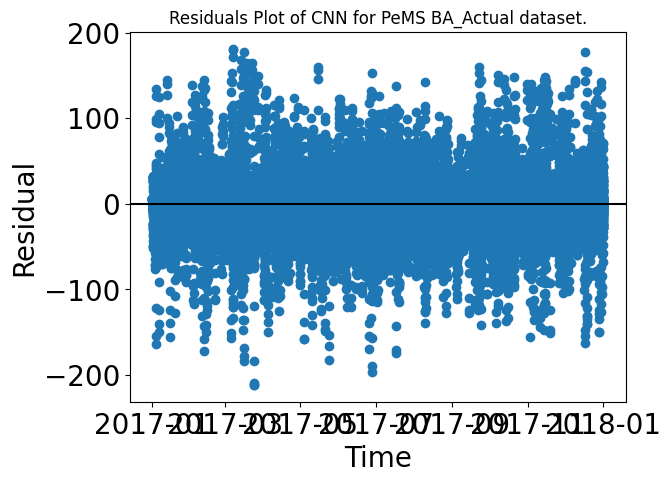

In [71]:
actual_arr_CNN = np.array(results_CNN['Actual'])
predicted_arr_CNN = np.array(results_CNN['Predicted'])
residuals_CNN = predicted_arr_CNN - actual_arr_CNN
plt.scatter(results_CNN['Date'], residuals_CNN)
plt.axhline(y=0, color = 'black')
plt.title("Residuals Plot of CNN for PeMS {} dataset.".format(feature_field))
#plt.locator_params(axis='x', nbins=10)
#plt.locator_params(axis='y', nbins=10)
#plt.ylim([40, 70])
plt.xlabel("Time", fontsize = 20)
plt.ylabel("Residual", fontsize = 20)
plt.show()

From the residual plots for the CNN model, it can be concluded that the CNN model is a good fit.

### Energy Consumption

In [72]:
measure_time_and_energy(cnn_model, X_test)

Measuring inference time and estimating energy on CPU...
Model CPU inference time: 1.3710 seconds
Estimated CPU energy consumption (using general power value): 109.6797 J
Total CPU Energy: 109679660.8620 µJ

No GPU available in this runtime. Cannot measure GPU inference time or estimate energy.


# CNN-LSTM (Hybrid DNN) Model

## Create CNN-LSTM Model

In [73]:
cnn_lstm_model = Sequential()

cnn_lstm_model.add(Conv1D(filters=8, kernel_size=3, activation=activation,
                          input_shape=(40,1)))
cnn_lstm_model.add(MaxPooling1D(pool_size=2))

cnn_lstm_model.add(LSTM(8,activation=activation,return_sequences=False))
cnn_lstm_model.add(Dropout(0.1))

cnn_lstm_model.add(Dense(1))
cnn_lstm_model.compile(optimizer='adam', loss='mse')
cnn_lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 38, 8)          │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 19, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 8)              │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 585 (2.29 KB)

 Trainable params: 585 (2.29 KB)

 Non-trainable params: 0 (0.00 B)

## Train CNN-LSTM Model

Epoch 1/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0567
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0162
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0128
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0100
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0082
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0072
Epoch 7/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0064
Epoch 8/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0059
Epoch 9/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0057
Epoch 10/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0053


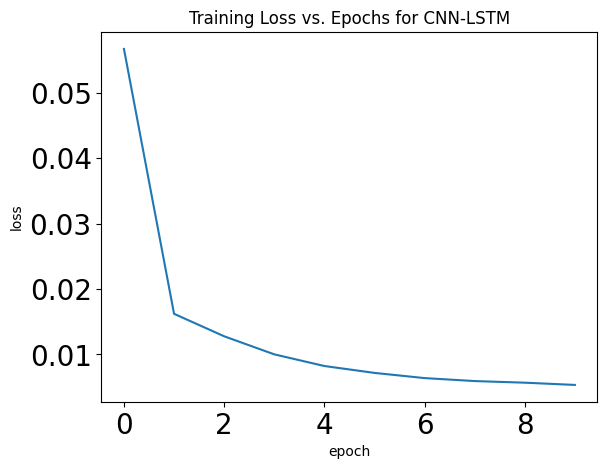

In [74]:
cnn_lstm_model.compile(optimizer="adam",loss=loss)
cnn_lstm_epochs = cnn_lstm_model.fit(X_train, y_train, epochs=epochs,
                                     batch_size=batch_size)
plot_training_loss(cnn_lstm_epochs, "CNN-LSTM")

## Evaluate CNN-LSTM Model using MAE, RMSE, and R2.

In [75]:
print("CNN-LSTM Predictions for Training Set")
cnn_lstm_pred_train = cnn_lstm_model.predict(X_train)
print("CNN-LSTM Predictions for Testing Set")
cnn_lstm_pred_test = cnn_lstm_model.predict(X_test)
cnn_lstm_mae = mean_absolute_error(y_test,cnn_lstm_pred_test)
print("MAE of CNN-LSTM model = ",cnn_lstm_mae)
cnn_lstm_rmse =  mean_squared_error(y_test,cnn_lstm_pred_test) ** 0.5
print("RMSE of CNN-LSTM model = ",cnn_lstm_rmse)
cnn_lstm_r2_score = r2_score(y_test, cnn_lstm_pred_test)
print("R^2 Score of CNN-LSTM model = ",cnn_lstm_r2_score)
cnn_lstm_mape_score = 100*mean_absolute_percentage_error(y_test,
                                                         cnn_lstm_pred_test)
print("MAPE Score of CNN-LSTM model = {0} %".format(cnn_lstm_mape_score))

CNN-LSTM Predictions for Training Set
2628/2628 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step
CNN-LSTM Predictions for Testing Set
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
MAE of CNN-LSTM model =  0.022449161586986923
RMSE of CNN-LSTM model =  0.047162675136633206
R^2 Score of CNN-LSTM model =  0.9779323789216384
MAPE Score of CNN-LSTM model = 2303473632325942.0 %


## Reverse Transform Scaler to Convert to Real Values.

In [76]:
y_train_inverse = scaler.inverse_transform(y_train.reshape(-1, 1))
cnn_lstm_pred_inv_train = scaler.inverse_transform(cnn_lstm_pred_train)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))
cnn_lstm_pred_inv_test = scaler.inverse_transform(cnn_lstm_pred_test)

# Get values after inverse transformation.
y_train_inverse = y_train_inverse.flatten()
cnn_lstm_pred_inv_train = cnn_lstm_pred_inv_train.flatten()
y_test_inverse = y_test_inverse.flatten()
cnn_lstm_pred_inv_test = cnn_lstm_pred_inv_test.flatten()

## Showing Actual y and Predicted y values as Dataframes.

In [77]:
results_CNN_LSTM_train = pd.DataFrame({"Date":first_6169_index_dates,
                                 'Actual': y_train_inverse,
                                 'Predicted': cnn_lstm_pred_inv_train})
results_CNN_LSTM_train

,Date,Actual,Predicted
0,2017-01-01 00:00:00+00:00,0.0,1.745103
1,2017-01-01 00:05:00+00:00,0.0,1.745103
2,2017-01-01 00:10:00+00:00,0.0,1.745103
3,2017-01-01 00:15:00+00:00,0.0,1.745103
4,2017-01-01 00:20:00+00:00,0.0,1.745103
...,...,...,...
84091,2017-10-19 23:35:00+00:00,0.0,1.125093
84092,2017-10-19 23:40:00+00:00,0.0,1.376544
84093,2017-10-19 23:45:00+00:00,0.0,1.537788
84094,2017-10-19 23:50:00+00:00,0.0,1.646334


In [78]:
# Now let's see our actual y and predicted y values as dataframes
results_CNN_LSTM_test = pd.DataFrame({"Date":last_6169_index_dates,
                                 'Actual': y_test_inverse,
                                 'Predicted': cnn_lstm_pred_inv_test})
results_CNN_LSTM_test

,Date,Actual,Predicted
0,2017-10-20 01:40:00+00:00,0.0000,1.745103
1,2017-10-20 01:45:00+00:00,0.0000,1.745103
2,2017-10-20 01:50:00+00:00,0.0000,1.745103
3,2017-10-20 01:55:00+00:00,0.0000,1.745103
4,2017-10-20 02:00:00+00:00,0.0000,1.745103
...,...,...,...
20999,2017-12-31 23:35:00+00:00,0.8568,10.744632
21000,2017-12-31 23:40:00+00:00,1.9992,6.062407
21001,2017-12-31 23:45:00+00:00,0.0000,1.617323
21002,2017-12-31 23:50:00+00:00,0.0000,0.187743


## Plotting Predictions for Monthly Mean Sunspot Number made by CNN-LSTM Model.

#### Only Testing Data.

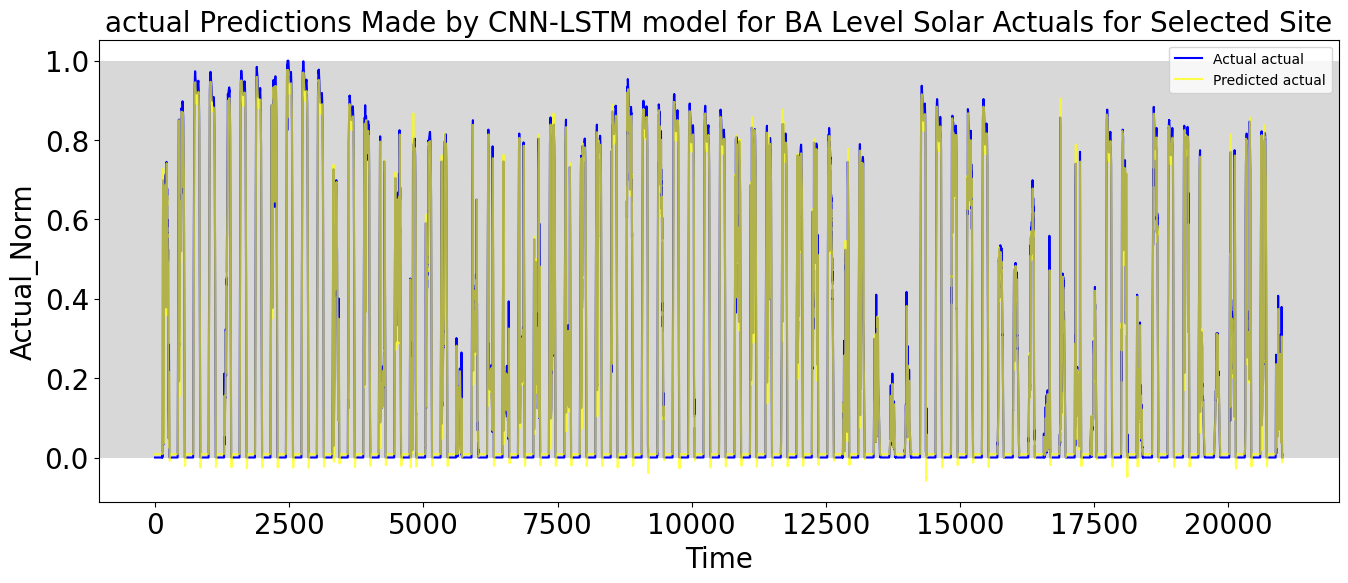

In [79]:
plt.figure(figsize=(16,6))
plt.plot(y_test, color='blue',label='Actual {0}'.format(feature))
plt.plot(cnn_lstm_pred_test, alpha=0.7, color='yellow', \
         label='Predicted {0}'.format(feature))
plt.axhspan(0, 1, facecolor='gray', alpha=0.3)
plt.title("{0} Predictions Made by CNN-LSTM model for {1}".
          format(feature, title_name), fontsize = 20)
plt.locator_params(axis='x', nbins=10)
plt.locator_params(axis='y', nbins=10)
#plt.ylim([40, 70])
plt.xlabel('Time', fontsize = 20)
plt.ylabel(feature_norm, fontsize = 20)
plt.legend()
plt.show()

#### Training and Test Data Combined.

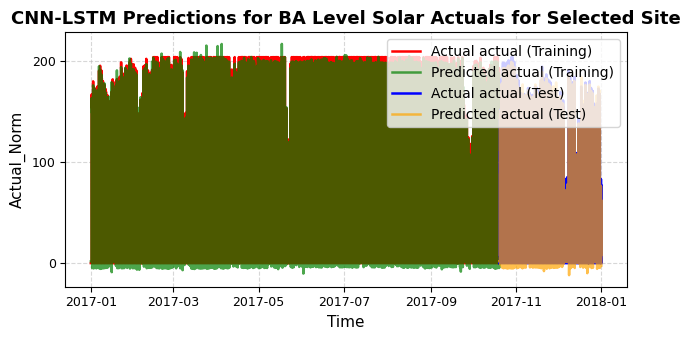

In [80]:
# 🔹 Create figure sized for IEEE 2-column layout
plt.figure(figsize=(6.5, 3.5))  # 6.5in width fits one column in IEEE

# 🔹 Plot training data
plt.plot(results_CNN_LSTM_train['Date'], results_CNN_LSTM_train['Actual'],
         color='red', label=f'Actual {feature} (Training)', linewidth=1.8)
plt.plot(results_CNN_LSTM_train['Date'], results_CNN_LSTM_train['Predicted'],
         color='green', label=f'Predicted {feature} (Training)', alpha=0.7,
         linewidth=1.8)

# 🔹 Plot test data
plt.plot(results_CNN_LSTM_test['Date'], results_CNN_LSTM_test['Actual'],
         color='blue', label=f'Actual {feature} (Test)', linewidth=1.8)
plt.plot(results_CNN_LSTM_test['Date'], results_CNN_LSTM_test['Predicted'],
         color='orange', label=f'Predicted {feature} (Test)', alpha=0.7,
         linewidth=1.8)

# 🔹 Formatting
plt.title(f'CNN-LSTM Predictions for {title_name}', fontsize=13, fontweight='bold')
plt.xlabel('Time', fontsize=11)
plt.ylabel(feature_norm, fontsize=11)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# 🔹 Export for Appendix
plt.show()

## Combine Actual and Predicted Results for Train and Test Cases for CNN-LSTM.

In [81]:
results_CNN_LSTM = [results_CNN_LSTM_train, results_CNN_LSTM_test]
results_CNN_LSTM = pd.concat(results_CNN_LSTM)
display(results_CNN_LSTM)

,Date,Actual,Predicted
0,2017-01-01 00:00:00+00:00,0.0000,1.745103
1,2017-01-01 00:05:00+00:00,0.0000,1.745103
2,2017-01-01 00:10:00+00:00,0.0000,1.745103
3,2017-01-01 00:15:00+00:00,0.0000,1.745103
4,2017-01-01 00:20:00+00:00,0.0000,1.745103
...,...,...,...
20999,2017-12-31 23:35:00+00:00,0.8568,10.744632
21000,2017-12-31 23:40:00+00:00,1.9992,6.062407
21001,2017-12-31 23:45:00+00:00,0.0000,1.617323
21002,2017-12-31 23:50:00+00:00,0.0000,0.187743


## Plotting Residuals for Actual and Predicted Results for CNN-LSTM.

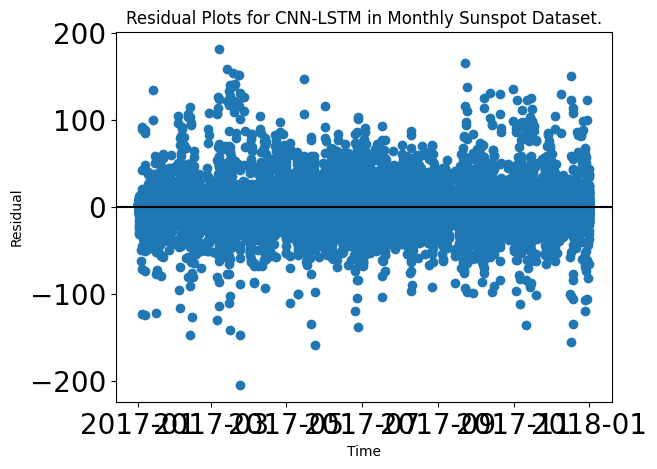

In [82]:
actual_arr_CNN_LSTM = np.array(results_CNN_LSTM['Actual'])
predicted_arr_CNN_LSTM = np.array(results_CNN_LSTM['Predicted'])
residuals_CNN_LSTM = predicted_arr_CNN_LSTM - actual_arr_CNN_LSTM
plt.scatter(results_CNN_LSTM['Date'], residuals_CNN_LSTM)
plt.axhline(y=0, color = 'black')
plt.title("Residual Plots for CNN-LSTM in Monthly Sunspot Dataset.")
#plt.locator_params(axis='x', nbins=10)
#plt.locator_params(axis='y', nbins=10)
#plt.ylim([40, 70])
plt.xlabel("Time")
plt.ylabel("Residual")
plt.show()

## Energy Consumption

In [83]:
measure_time_and_energy(cnn_lstm_model, X_test)

Measuring inference time and estimating energy on CPU...
Model CPU inference time: 2.2223 seconds
Estimated CPU energy consumption (using general power value): 177.7825 J
Total CPU Energy: 177782459.3175 µJ

No GPU available in this runtime. Cannot measure GPU inference time or estimate energy.


# Forecasting Future Data for all models

## Essential Functions.

In [84]:
# this section for unknown future.
future=20
#future=seq_len
forecast_LSTM = []
forecast_DSNN = []
forecast_CNN_LSTM = []

In [85]:
def insert_end(Xin, new_input, timestep):
    for i in range(timestep-1):
        Xin[:,i,:] = Xin[:,i+1,:]
    Xin[:,timestep-1,:] = new_input
    return Xin

def forecast_data(Xin, model_type, forecast, future_num):
    time=[]
    data_pts = future_num
    for j in range(data_pts):
      out = model_type.predict(Xin, batch_size=1000)
      forecast.append(out[j, 0])
      Xin = insert_end(Xin, out[j, 0], future_num)
      time_current = pd.to_datetime(df_norm.index[-1])+timedelta(days=30*j)
      if (j % 100 == 0):
        print("j = {0}".format(j))
        print("forecast: {0}".format(forecast))
        print("time_current: ",  time_current)
      time.append(time_current)


    forcasted_output=np.asanyarray(forecast)
    forcasted_output=forcasted_output.reshape(-1,1)
    forcasted_output = scaler.inverse_transform(forcasted_output)
    forcasted_output = pd.DataFrame(forcasted_output)
    date = pd.DataFrame(time)
    forecast_result = pd.concat([date, forcasted_output],axis=1)
    forecast_result.columns = "Date","Forecasted"

    return forecast_result

In [86]:
# Plotting Predictions and Forecast for Monthly Mean Sunspot Number.
def plot_forecast(forecast_set, model_name, mode, min=140, max=165):
    plt.figure(figsize=(16,6))
    plt.plot(forecast_set['Date'], forecast_set['Forecasted'], alpha=0.7,
             color='teal', label='Forecasted {0}'.format(feature))
    plt.axhspan(0, 1, facecolor='gray', alpha=0.3)
    plt.title('{0} Forecast for {1} using {2}'.
              format(feature_field, mode, model_name), fontsize = 15)
    plt.locator_params(axis='x', nbins=10)
    plt.locator_params(axis='y', nbins=10)
    #plt.ylim([40, 70])
    plt.xlabel('Time', fontsize = 20)
    plt.ylabel(feature_field, fontsize = 20)
    plt.rc('xtick', labelsize=10)
    plt.rc('ytick', labelsize=10)
    plt.legend()
    plt.show()

In [87]:
# Plotting Predictions for Vehicle Hours/Miles.
def plot_with_forecast(train_set, test_set, forecast_set, model_name,
                       mode):
    plt.figure(figsize=(16,6))
    plt.plot(train_set['Date'], train_set['Actual'], color='red',
             label='Actual {0} (Training Case)'.format(feature))
    plt.plot(train_set['Date'], train_set['Predicted'], alpha=0.7,
             color='green',
             label='Predicted {0} (Training Case)'.format(feature))
    plt.plot(test_set['Date'], test_set['Actual'], color='blue',
            label='Actual {0} (Test Case)'.format(feature))
    plt.plot(test_set['Date'], test_set['Predicted'], alpha=0.7, color='yellow',
             label='Predicted {0} (Test Case)'.format(feature))
    plt.plot(forecast_set['Date'], forecast_set['Forecasted'], alpha=0.7,
             color='teal', label='Forecasted {0}'.format(feature))
    plt.axhspan(0, 1, facecolor='gray', alpha=0.3)
    plt.title("{0} Predictions and Forecasts made by {1} model for {2}".
              format(feature_field, model_name, title_name), fontsize = 15)
    plt.locator_params(axis='x', nbins=10)
    plt.locator_params(axis='y', nbins=10)
    plt.rc('xtick', labelsize=10)
    plt.rc('ytick', labelsize=10)
    #plt.ylim([1052, 1054])
    plt.xlabel('Time', fontsize = 15)
    plt.ylabel('Normalized {0} Scale'.format(feature_field), fontsize = 15)
    plt.legend()
    plt.show()

## Forecasting Future Data for LSTM.

In [88]:
Xin = X_test[:,:,:]
Xin

array([[[0.        ],
        [0.        ],
        [0.        ],
        ...,
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        ...,
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        ...,
        [0.        ],
        [0.        ],
        [0.        ]],

       ...,

       [[0.05882353],
        [0.05462185],
        [0.04901961],
        ...,
        [0.00840336],
        [0.00420168],
        [0.00980392]],

       [[0.05462185],
        [0.04901961],
        [0.04481793],
        ...,
        [0.00420168],
        [0.00980392],
        [0.        ]],

       [[0.04901961],
        [0.04481793],
        [0.04061625],
        ...,
        [0.00980392],
        [0.        ],
        [0.        ]]])

In [89]:
#Xin_reshaped_LSTM = Xin.reshape(Xin.shape[0], Xin.shape[2], 1)
forecast_result_lstm = forecast_data(Xin, lstm_model, forecast_LSTM, future)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
j = 0
forecast: [np.float32(0.037861243)]
time_current:  2017-12-31 23:55:00+00:00
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [90]:
forecast_result_lstm

,Date,Forecasted
0,2017-12-31 23:55:00+00:00,7.720604
1,2018-01-30 23:55:00+00:00,9.615388
2,2018-03-01 23:55:00+00:00,11.666870
3,2018-03-31 23:55:00+00:00,13.811796
4,2018-04-30 23:55:00+00:00,16.028282
5,2018-05-30 23:55:00+00:00,18.289022
6,2018-06-29 23:55:00+00:00,20.566118
7,2018-07-29 23:55:00+00:00,22.833092
8,2018-08-28 23:55:00+00:00,25.066059
9,2018-09-27 23:55:00+00:00,27.244328


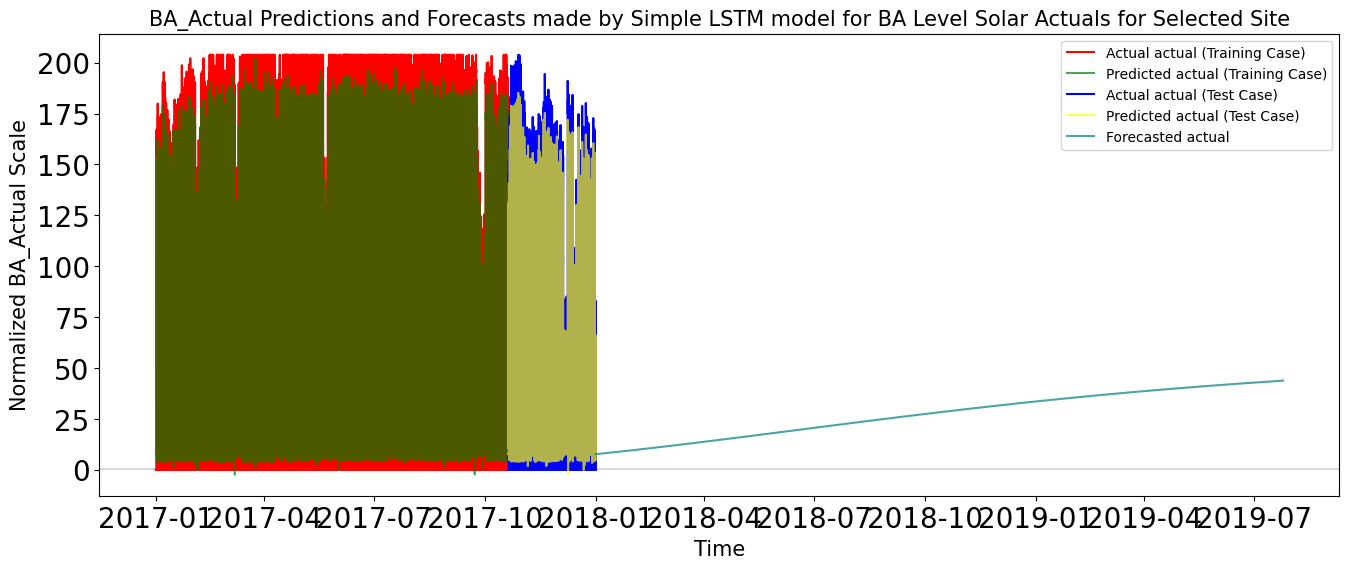

In [91]:
# Plot Forecast combined with Training and Testing Data.
plot_with_forecast(results_LSTM_train, results_LSTM_test, forecast_result_lstm,
                   'Simple LSTM', title_name)

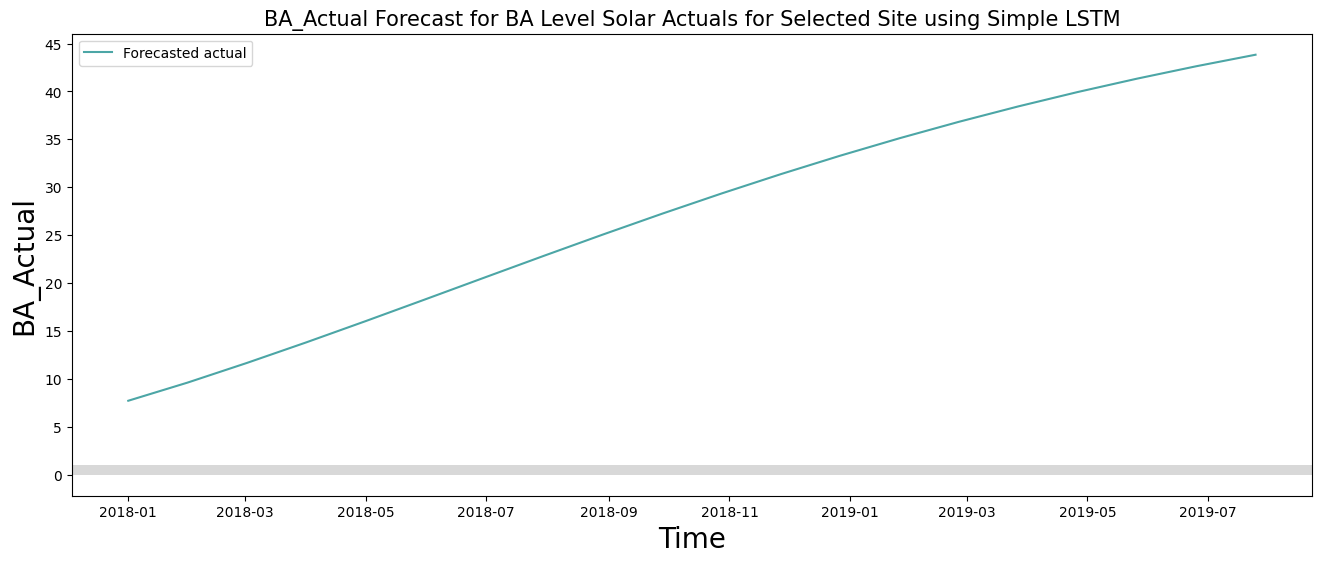

In [92]:
# Only Forecast Data for closer look.
plot_forecast(forecast_result_lstm, 'Simple LSTM', title_name)

## Forecasting Future Data for CNN-LSTM

In [93]:
forecast_result_cnn_lstm = forecast_data(Xin, cnn_lstm_model, forecast_CNN_LSTM,
                                         future)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
j = 0
forecast: [np.float32(0.21561292)]
time_current:  2017-12-31 23:55:00+00:00
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [94]:
forecast_result_cnn_lstm

,Date,Forecasted
0,2017-12-31 23:55:00+00:00,43.967442
1,2018-01-30 23:55:00+00:00,44.792343
2,2018-03-01 23:55:00+00:00,45.069386
3,2018-03-31 23:55:00+00:00,45.595493
4,2018-04-30 23:55:00+00:00,45.695461
5,2018-05-30 23:55:00+00:00,45.943245
6,2018-06-29 23:55:00+00:00,45.854694
7,2018-07-29 23:55:00+00:00,45.862381
8,2018-08-28 23:55:00+00:00,45.596798
9,2018-09-27 23:55:00+00:00,45.388298


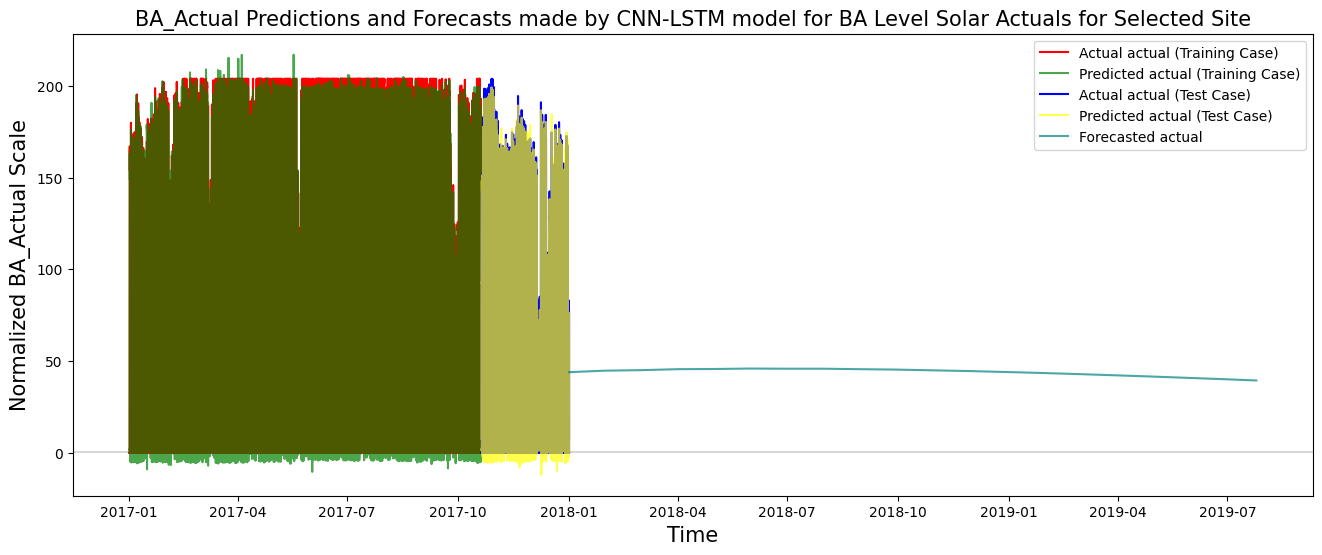

In [95]:
# Plot Forecast combined with Training and Testing Data.
plot_with_forecast(results_CNN_LSTM_train, results_CNN_LSTM_test,
                   forecast_result_cnn_lstm , 'CNN-LSTM', title_name)

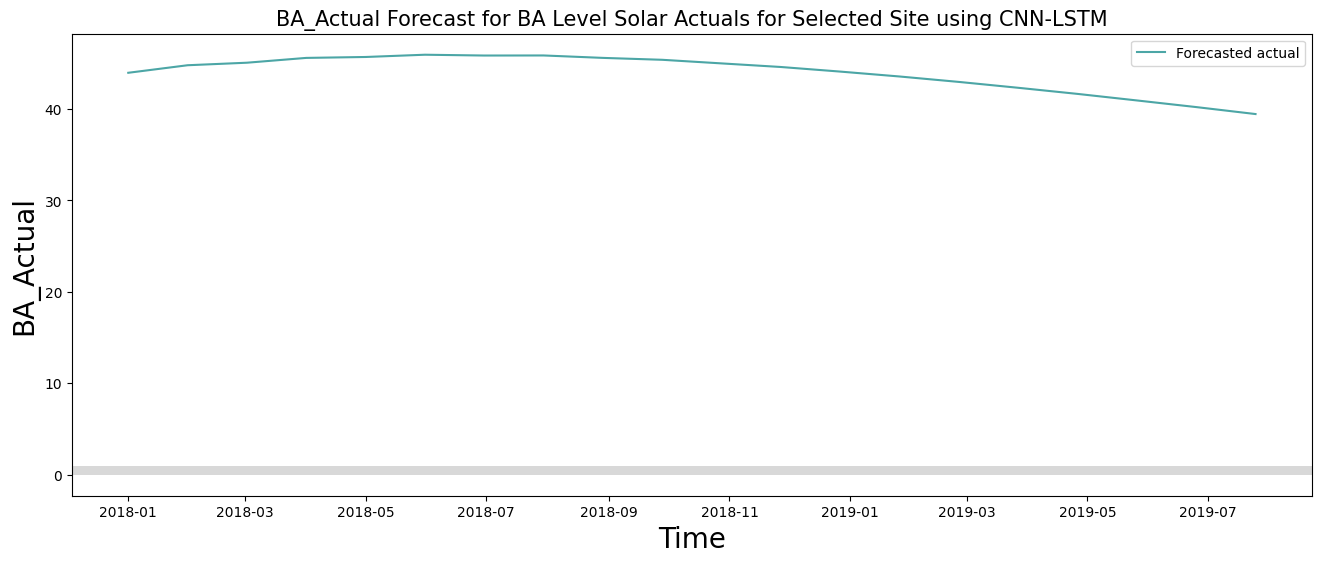

In [96]:
# Only Forecast Data for closer look.
plot_forecast(forecast_result_cnn_lstm, 'CNN-LSTM', title_name)